# Problem 3 — Impact of Noise on the Dynamic Long-Range CNOT

**2026 Quantum Hackathon — Dynamic Circuits**

Reference: Bäumer *et al.*, PRX Quantum **5**, 030339 (2024).

---

## Objective

Analyze how **depolarizing noise**, **readout error**, and **thermal relaxation (T₁/T₂)** degrade fidelity of the dynamic long-range CNOT as the number of intermediate ancilla qubits $n$ increases.

The error budget decomposes as:

$$\lambda_{\text{tot}} = t_{\text{idle}}\,\lambda_{\text{idle}} + N_{\text{CNOT}}\,\lambda_{\text{CNOT}} + N_{\text{meas}}\,\lambda_{\text{meas}}, \qquad F_{\text{proc}} \geq e^{-\lambda_{\text{tot}}}$$

In [1]:
from __future__ import annotations

import math, gc, warnings
from collections import deque
from dataclasses import dataclass
from statistics import median

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qiskit.result import marginal_counts
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import IfElseOp, Reset
from qiskit.circuit.classical import expr
from qiskit.transpiler import CouplingMap, Layout, generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, ReadoutError,
    depolarizing_error, thermal_relaxation_error,
)

warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.style.use("seaborn-v0_8-whitegrid")

SHOTS = 4096
SEED = 2026
np.random.seed(SEED)
print("Imports complete.")

Imports complete.


## Step 0 — Backend Selection

아래 셀에서 사용할 **Fake Backend**를 선택하세요. `BACKEND_NAME`을 바꾸면 다른 백엔드로 전환됩니다.

사용 가능한 백엔드 예시:
- `"FakeBrisbane"` — 127-qubit Eagle r3, heavy-hex
- `"FakeSherbrooke"` — 127-qubit Eagle r3, heavy-hex
- `"FakeKyoto"` — 127-qubit Eagle r3, heavy-hex
- `"FakeOsaka"` — 127-qubit Eagle r3, heavy-hex
- `"FakeTorino"` — 133-qubit Heron r1
- `"FakeQuebec"` — 127-qubit Eagle r1
- `"FakeMontreal"` — 27-qubit Falcon r4

> 원하는 백엔드 이름을 아래 `BACKEND_NAME`에 넣으면 자동으로 로드됩니다.

In [2]:
# ============================================================
# >>>  여기서 백엔드를 선택하세요  <<<
# ============================================================
BACKEND_NAME = "FakeBrisbane"
# BACKEND_NAME = "FakeSherbrooke"
# BACKEND_NAME = "FakeKyoto"
# BACKEND_NAME = "FakeOsaka"
# BACKEND_NAME = "FakeTorino"
# BACKEND_NAME = "FakeQuebec"
# BACKEND_NAME = "FakeMontreal"

# ============================================================

from qiskit_ibm_runtime import fake_provider as _fp

_available = {name: getattr(_fp, name)
              for name in dir(_fp)
              if name.startswith("Fake") and name[4:5].isupper()
              and callable(getattr(_fp, name, None))}

if BACKEND_NAME not in _available:
    print(f"'{BACKEND_NAME}' not found. Available backends:")
    for k in sorted(_available):
        print(f"  {k}")
    raise ValueError(f"Unknown backend: {BACKEND_NAME}")

backend_ref = _available[BACKEND_NAME]()

# Ensure dynamic-circuit instruction support
for instr_cls, instr_name in [(IfElseOp, "if_else"), (Reset, "reset")]:
    if instr_name not in backend_ref.target.operation_names:
        backend_ref.target.add_instruction(instr_cls, name=instr_name)

print(f"Selected backend: {backend_ref.name}")
print(f"  Qubits: {backend_ref.num_qubits}")
print(f"  Native gates: {sorted(set(backend_ref.target.operation_names) - {'if_else','reset','measure','delay','barrier'})}")

Selected backend: fake_brisbane
  Qubits: 127
  Native gates: ['ecr', 'for_loop', 'id', 'rz', 'switch_case', 'sx', 'x']


In [3]:
# ----- Distances -----
SIM_DISTANCES    = [0, 1, 2, 4, 6, 8, 10, 14, 18]
BUDGET_DISTANCES = list(range(0, 51))
BASES            = ["XX", "YY", "ZZ"]
IMPLEMENTATIONS  = ["dynamic", "unitary_ic"]

# ----- Feed-forward latency (ns) — paper reports ~0.7 us -----
FEEDFORWARD_TIME_NS = 700.0

# ----- Real backend toggle (Part 6) -----
USE_REAL_BACKEND = True

# ----- Reference budget parameters (paper Fig. 7) -----
DEFAULT_BUDGET_PARAMS = {
    "mu": 3.65,
    "lambda_idle": 0.03,
    "lambda_cnot": 0.02,
    "lambda_meas": 0.03,
}

print(f"Simulation distances: {SIM_DISTANCES}")
print(f"Budget distances: 0 .. {max(BUDGET_DISTANCES)}")

Simulation distances: [0, 1, 2, 4, 6, 8, 10, 14, 18]
Budget distances: 0 .. 50


## Step 1 — Lambda Conversion Functions (Appendix G & C)

Backend calibration 데이터를 Pauli-Lindblad rate ($\lambda$)로 변환하는 핵심 함수들입니다.

**Idle decoherence** (Appendix G, Eq. G7):
$$\lambda_{\text{idle}} = t_{\text{CNOT}} \left(\frac{1}{2T_1} + \frac{1}{2T_2}\right)$$

**CNOT gate error** (Appendix C, Eq. C13):
$$F_{\text{proc}} = \frac{(d+1)F_{\text{gate}} - 1}{d}, \quad \lambda_{\text{CNOT}} = -\log F_{\text{proc}} \quad (d=4)$$

**Readout / measurement error** (Eq. G1):
$$\lambda_{\text{meas}} = -\log(1 - p)$$

In [4]:
def _error_probability_to_lambda(probability: float) -> float:
    """Convert calibration error probability to Pauli-Lindblad rate.
    
    For readout error probability p, the exact Pauli-Lindblad rate is
    lambda = -log(1 - p)  (Eq. G1).
    """
    p = min(max(float(probability), 0.0), 1.0 - 1e-12)
    return float(-np.log(1.0 - p))


def _idle_lambda_per_cnot_time(t1_ns: float, t2_ns: float, cnot_time_ns: float) -> float:
    """Idle decoherence rate over one CNOT-gate duration (Appendix G, Eq. G7).
    
    Combined amplitude-damping (t/4T1 for X, t/4T1 for Y) and
    phase-damping (t/2T2 for Z) gives total idle rate per CNOT-time:
        lambda_idle = t_CNOT * (1/(2*T1) + 1/(2*T2))
    """
    if min(t1_ns, t2_ns, cnot_time_ns) <= 0:
        return DEFAULT_BUDGET_PARAMS["lambda_idle"]
    return float(cnot_time_ns * (1.0 / (2.0 * t1_ns) + 1.0 / (2.0 * t2_ns)))


def _cnot_lambda_per_operation(cnot_gate_error: float, dimension: int = 4) -> float:
    """Budget-effective CNOT rate from average gate error (Appendix C, Eq. C13).
    
    Qiskit gate_error is average gate error: F_gate = 1 - gate_error.
    Process fidelity: F_proc = ((d+1)*F_gate - 1) / d,  d=4 for 2-qubit.
    Budget rate: lambda_CNOT = -log(F_proc).
    """
    gate_error = min(max(float(cnot_gate_error), 0.0), 1.0 - 1e-12)
    gate_fidelity = 1.0 - gate_error
    process_fidelity = ((dimension + 1.0) * gate_fidelity - 1.0) / dimension
    process_fidelity = min(max(process_fidelity, 1e-12), 1.0)
    return float(-np.log(process_fidelity))


print("Lambda conversion functions defined.")

Lambda conversion functions defined.


## Step 2 — Hardware Calibration Extraction

선택한 Fake Backend에서 T₁, T₂, gate error, readout error, gate duration 등을 추출하고, $\lambda$ rate로 변환합니다.

In [5]:
TWO_Q_NAMES = {"cx", "ecr", "cz"}

def median_2q_duration(backend):
    durs = []
    for name in TWO_Q_NAMES:
        if name not in backend.target.operation_names: continue
        for _, p in backend.target[name].items():
            if p and p.duration: durs.append(p.duration)
    return float(median(durs)) if durs else 68e-9

def median_2q_error(backend):
    errs = []
    for name in TWO_Q_NAMES:
        if name not in backend.target.operation_names: continue
        for _, p in backend.target[name].items():
            if p and p.error is not None: errs.append(p.error)
    return float(median(errs)) if errs else 0.01

def median_readout_err(backend, qubits=None):
    if "measure" not in backend.target.operation_names: return 0.02
    qubits = qubits or list(range(min(30, len(backend.target.qubit_properties))))
    errs = []
    for q in qubits:
        p = backend.target["measure"].get((q,))
        if p and p.error is not None: errs.append(p.error)
    return float(median(errs)) if errs else 0.02

def median_t1_t2_us(backend, qubits=None):
    props = backend.target.qubit_properties
    qubits = qubits or list(range(len(props)))
    t1s = [props[q].t1 * 1e6 for q in qubits if props[q] and props[q].t1]
    t2s = [props[q].t2 * 1e6 for q in qubits if props[q] and props[q].t2]
    return float(median(t1s)) if t1s else 100.0, float(median(t2s)) if t2s else 50.0

def median_meas_time_ns(backend):
    if "measure" not in backend.target.operation_names: return 800.0
    durs = []
    for _, p in backend.target["measure"].items():
        if p and p.duration: durs.append(p.duration * 1e9)
    return float(median(durs)) if durs else 800.0


# ---- Extract from selected backend ----
t_2q_s   = median_2q_duration(backend_ref)
gate_err = median_2q_error(backend_ref)
ro_err   = median_readout_err(backend_ref)
t1_us, t2_us = median_t1_t2_us(backend_ref)
t_meas_ns = median_meas_time_ns(backend_ref)

# Convert to ns
t_2q_ns = t_2q_s * 1e9
t1_ns   = t1_us * 1e3
t2_ns   = min(t2_us * 1e3, 2.0 * t1_ns)

# Compute calibrated budget parameters
mu_cal          = (t_meas_ns + FEEDFORWARD_TIME_NS) / t_2q_ns
lambda_idle_cal = _idle_lambda_per_cnot_time(t1_ns, t2_ns, t_2q_ns)
lambda_cnot_cal = _cnot_lambda_per_operation(gate_err, dimension=4)
lambda_meas_cal = _error_probability_to_lambda(ro_err)

CALIBRATED_BUDGET = {
    "mu": mu_cal,
    "lambda_idle": lambda_idle_cal,
    "lambda_cnot": lambda_cnot_cal,
    "lambda_meas": lambda_meas_cal,
}

# Display
cal_df = pd.DataFrame([{
    "backend": backend_ref.name,
    "qubits": backend_ref.num_qubits,
    "T1 (us)": round(t1_us, 1),
    "T2 (us)": round(t2_us, 1),
    "t_2q (ns)": round(t_2q_ns, 1),
    "t_meas (ns)": round(t_meas_ns, 1),
    "gate_err": round(gate_err, 5),
    "readout_err": round(ro_err, 5),
}])

lam_df = pd.DataFrame([{
    "mu": round(mu_cal, 3),
    "lambda_idle": round(lambda_idle_cal, 6),
    "lambda_CNOT": round(lambda_cnot_cal, 6),
    "lambda_meas": round(lambda_meas_cal, 6),
    "3*lambda_CNOT": round(3*lambda_cnot_cal, 6),
    "crossover met?": lambda_meas_cal < 3*lambda_cnot_cal,
}])

print(f"=== {backend_ref.name} Hardware Calibration ===")
display(cal_df)
print(f"\n=== Derived Lambda Rates ===")
print(f"  lambda_idle  = t_CNOT*(1/2T1 + 1/2T2)     = {lambda_idle_cal:.6f}")
print(f"  lambda_CNOT  = -log(F_proc)                = {lambda_cnot_cal:.6f}  [F_gate={1-gate_err:.5f}]")
print(f"  lambda_meas  = -log(1-p_ro)                = {lambda_meas_cal:.6f}  [p_ro={ro_err:.5f}]")
print(f"  mu           = (t_meas+t_ff)/t_CNOT        = {mu_cal:.3f}")
display(lam_df)

=== fake_brisbane Hardware Calibration ===


,backend,qubits,T1 (us),T2 (us),t_2q (ns),t_meas (ns),gate_err,readout_err
0,fake_brisbane,127,232.0,150.0,660.0,1300.0,0.00772,0.02283



=== Derived Lambda Rates ===
  lambda_idle  = t_CNOT*(1/2T1 + 1/2T2)     = 0.003622
  lambda_CNOT  = -log(F_proc)                = 0.009696  [F_gate=0.99228]
  lambda_meas  = -log(1-p_ro)                = 0.023092  [p_ro=0.02283]
  mu           = (t_meas+t_ff)/t_CNOT        = 3.030


,mu,lambda_idle,lambda_CNOT,lambda_meas,3*lambda_CNOT,crossover met?
0,3.03,0.003622,0.009696,0.023092,0.029088,True


## Step 3 — Circuit Builders

**Dynamic LRCX**: Gate teleportation, O(1) quantum depth.
**Unitary Ic**: Full round-trip SWAP, N_CNOT = 4n+1, t_idle = 0.

In [6]:
# ==================== Dynamic LRCX ====================

def check_even(n: int) -> int:
    return 1 if n % 2 == 0 else 2

def initialize_circuit(distance: int) -> QuantumCircuit:
    n = distance
    qr = QuantumRegister(n + 2, name="q")
    cr = ClassicalRegister(2, name="cr")
    k = int(n / 2)
    allcr = [cr]
    if distance > 1:
        allcr.append(ClassicalRegister(k, name="c1"))
    if distance > 0:
        allcr.append(ClassicalRegister(n - k, name="c2"))
    qc = QuantumCircuit(qr, *allcr, name="LRCX")
    qc.h(0)
    return qc

def prepare_bell_pairs(qc):
    n = qc.num_qubits - 2; k = int(n / 2); x0 = check_even(n)
    if n % 2 != 0: qc.cx(0, 1)
    for i in range(k):
        qc.h(x0 + 2*i); qc.cx(x0 + 2*i, x0 + 2*i + 1)
    return qc

def measure_bell_basis(qc):
    n = qc.num_qubits - 2; k = int(n / 2)
    if n > 1: _, c1, c2 = qc.cregs
    elif n > 0: _, c2 = qc.cregs
    x0 = 1 if n % 2 == 0 else 2
    for i in range(k + 1): qc.cx(x0 - 1 + 2*i, x0 + 2*i)
    for i in range(1, k + x0): qc.h(2*i + 1 - x0)
    qc.barrier()
    for i in range(k): qc.measure(2*i + x0, c1[i])
    for i in range(1, k + x0): qc.measure(2*i + 1 - x0, c2[i - 1])
    for q in range(1, n + 1): qc.reset(q)
    return qc

def apply_ffwd_corrections(qc):
    control, target = 0, qc.num_qubits - 1
    n = qc.num_qubits - 2; k = int(n / 2); x0 = check_even(n)
    if n > 1: _, c1, c2 = qc.cregs
    elif n > 0: _, c2 = qc.cregs
    parity_ZZ = parity_XX = None
    for i in range(k):
        parity_ZZ = expr.lift(c1[i]) if i == 0 else expr.bit_xor(c1[i], parity_ZZ)
    for i in range(1, k + x0):
        parity_XX = expr.lift(c2[i-1]) if i == 1 else expr.bit_xor(c2[i-1], parity_XX)
    if n > 0 and parity_XX is not None:
        with qc.if_test(parity_XX): qc.z(control)
    if n > 1 and parity_ZZ is not None:
        with qc.if_test(parity_ZZ): qc.x(target)
    return qc

def build_dynamic_lrcx(distance):
    qc = initialize_circuit(distance)
    qc = prepare_bell_pairs(qc)
    qc = measure_bell_basis(qc)
    qc = apply_ffwd_corrections(qc)
    return qc


# ==================== Unitary Ic ====================

def _validate_distance(distance):
    if distance is None:
        raise ValueError("Provide `distance`.")
    distance = int(distance)
    if distance < 0:
        raise ValueError("distance must be non-negative.")
    return distance


def _new_unitary_cnot_circuit(strategy, distance):
    distance = _validate_distance(distance)
    qr = QuantumRegister(distance + 2, "q")
    qc = QuantumCircuit(qr, name=f"CNOT_{strategy}")

    # Prepare |+> on the control qubit so that CNOT creates a Bell state.
    qc.h(0)

    qc.metadata = {
        "unitary_strategy": strategy,
        "distance": distance,
        "control_index": 0,
        "target_index": distance + 1,
    }
    return qc, distance

def _move_state_right(qc, left, right):
    """Move an unknown state from `left` into a right-neighbor `|0>` qubit."""
    qc.cx(left, right)
    qc.cx(right, left)


def _move_state_left(qc, right, left):
    """Move an unknown state from `right` into a left-neighbor `|0>` qubit."""
    qc.cx(right, left)
    qc.cx(left, right)


def _swap_via_cx(qc, a, b):
    qc.cx(a, b)
    qc.cx(b, a)
    qc.cx(a, b)

def build_unitary_cnot_ic(distance, add_barriers=True):
    """Strategy Ic: move both endpoint states to the middle and back."""
    qc, n = _new_unitary_cnot_circuit("Ic", distance=distance)
    k = n // 2
    last = n + 1

    for i in range(k):
        _move_state_right(qc, i, i + 1)
        _move_state_left(qc, last - i, last - i - 1)

    if n % 2 == 1:
        _move_state_left(qc, k + 2, k + 1)

    if add_barriers:
        qc.barrier()
    qc.cx(k, k + 1)
    if add_barriers:
        qc.barrier()

    for i in range(k):
        _move_state_left(qc, k - i, k - i - 1)
        _move_state_right(qc, k + 1 + i, k + 2 + i)

    if n % 2 == 1:
        _move_state_right(qc, last - 1, last)
    return qc

# ==================== Bell-test wrappers ====================

def _ensure_final_cr(qc):
    """
    Ensure that the circuit has a 2-bit final measurement register named 'cr'.
    Dynamic LRCX already has cr.
    Unitary Ic does not, so we add it.
    """
    if len(qc.cregs) > 0 and qc.cregs[0].name == "cr" and qc.cregs[0].size >= 2:
        return qc, qc.cregs[0]

    cr = ClassicalRegister(2, name="cr")
    qc.add_register(cr)
    return qc, cr


def _measure_in_basis(qc, basis):
    qc = qc.copy()
    qc, cr = _ensure_final_cr(qc)

    ctrl, tgt = 0, qc.num_qubits - 1

    qc.barrier()

    if basis == "XX":
        qc.h(ctrl)
        qc.h(tgt)

    elif basis == "YY":
        qc.sdg(ctrl)
        qc.sdg(tgt)
        qc.h(ctrl)
        qc.h(tgt)

    elif basis == "ZZ":
        pass

    else:
        raise ValueError(f"Unknown basis: {basis}")

    # Final Bell-test measurement
    qc.measure(ctrl, cr[0])
    qc.measure(tgt, cr[1])

    return qc


def build_bell_test_circuits(distance, impl):
    if impl == "dynamic": core = build_dynamic_lrcx(distance)
    elif impl == "unitary_ic": core = build_unitary_cnot_ic(distance)
    else: raise ValueError(impl)
    return [_measure_in_basis(core, b) for b in BASES]
    

def _corr_from_counts(counts):
    """
    Compute <Z ⊗ Z> from 2-bit final measurement counts.
    Assumes the two relevant classical bits are already marginalized.
    """
    total = sum(counts.values())

    corr = 0
    for bitstr, value in counts.items():
        bits = bitstr.replace(" ", "")

        # Use the final two measured bits.
        b0 = int(bits[-1])
        b1 = int(bits[-2])

        corr += ((-1) ** (b0 + b1)) * value

    return corr / total


# Sanity check
for impl in IMPLEMENTATIONS:
    circs = build_bell_test_circuits(2, impl)

    sim = AerSimulator(seed_simulator=SEED)
    res = sim.run(circs, shots=1024).result()

    raw_counts = [res.get_counts(i) for i in range(3)]

    # Final Bell-test register is 2 bits.
    # In most cases these are the last two classical bits after measurement.
    counts = []
    for c in raw_counts:
        c2 = marginal_counts(c, indices=[0, 1])
        counts.append(c2)

    ZZ = _corr_from_counts(counts[0])
    YY = _corr_from_counts(counts[1])
    XX = _corr_from_counts(counts[2])

    F = 0.25 * (1 + ZZ - YY + XX)

    print(f"  {impl:12s} ideal Bell fidelity = {F:.4f}")

print("Circuit builders ready.")

  dynamic      ideal Bell fidelity = 1.0000
  unitary_ic   ideal Bell fidelity = 1.0000
Circuit builders ready.


### Example Circuits (distance n = 4)

Dynamic LRCX (n=4): {'h': 5, 'cx': 5, 'measure': 4, 'reset': 4, 'if_else': 2, 'barrier': 1}
  qubits=6, depth=6


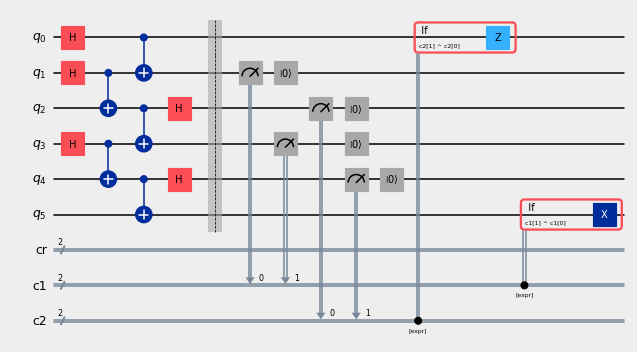

In [7]:
# Dynamic LRCX (gate teleportation, O(1) depth)
qc_dynamic = build_dynamic_lrcx(4)
print(f"Dynamic LRCX (n=4): {dict(qc_dynamic.count_ops())}")
print(f"  qubits={qc_dynamic.num_qubits}, depth={qc_dynamic.depth()}")
qc_dynamic.draw("mpl", fold=-1, scale=0.55,
                style={"backgroundcolor": "#EEEEEE"})

Unitary Ic (n=4): {'cx': 17, 'barrier': 2, 'h': 1}
  qubits=6, depth=10


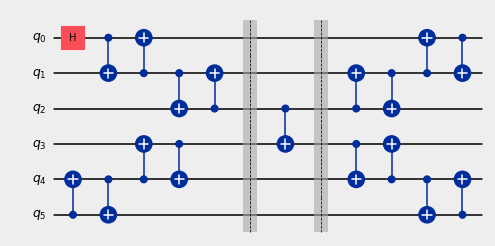

In [8]:
# Unitary Ic (zero-idle full SWAP, O(n) depth)
qc_unitary = build_unitary_cnot_ic(4)
print(f"Unitary Ic (n=4): {dict(qc_unitary.count_ops())}")
print(f"  qubits={qc_unitary.num_qubits}, depth={qc_unitary.depth()}")
qc_unitary.draw("mpl", fold=-1, scale=0.55,
                style={"backgroundcolor": "#EEEEEE"})

## Part 1 — Noise Models (Generic Aer Sweep용)

| Model | Description |
|---|---|
| `depolarizing` | 1Q + 2Q depolarizing |
| `readout` | Symmetric bit-flip |
| `thermal` | T₁/T₂ relaxation |
| `combined` | All composed |

여기서는 **백엔드 캘리브레이션 값**을 사용합니다.

In [9]:
# Noise parameters FROM the selected backend calibration
NOISE_PARAMS = {
    "p_depol_1q": 1.0e-4,       # 1Q gate error (small)
    "p_depol_2q": gate_err,     # from backend
    "p_readout":  ro_err,       # from backend
    "t1":   t1_ns,              # ns, from backend
    "t2":   t2_ns,              # ns, from backend
    "time_1q":   50,            # ns
    "time_2q":  t_2q_ns,        # ns, from backend
    "time_meas": t_meas_ns,     # ns, from backend
    "time_reset": t_meas_ns,    # ns
}

ONE_QUBIT_GATES = ["x", "z", "h", "sx", "id"]
TWO_QUBIT_GATES = ["cx"]

def two_qubit_thermal(t1, t2, gt):
    e = thermal_relaxation_error(t1, t2, gt); return e.tensor(e)

def make_noise_models(p):
    depol = NoiseModel()
    depol.add_all_qubit_quantum_error(depolarizing_error(p["p_depol_1q"], 1), ONE_QUBIT_GATES)
    depol.add_all_qubit_quantum_error(depolarizing_error(p["p_depol_2q"], 2), TWO_QUBIT_GATES)
    ro = NoiseModel()
    ro_err_mat = ReadoutError([[1-p["p_readout"],p["p_readout"]],[p["p_readout"],1-p["p_readout"]]])
    ro.add_all_qubit_readout_error(ro_err_mat)
    therm = NoiseModel()
    therm.add_all_qubit_quantum_error(thermal_relaxation_error(p["t1"],p["t2"],p["time_1q"]), ONE_QUBIT_GATES)
    therm.add_all_qubit_quantum_error(two_qubit_thermal(p["t1"],p["t2"],p["time_2q"]), TWO_QUBIT_GATES)
    therm.add_all_qubit_quantum_error(thermal_relaxation_error(p["t1"],p["t2"],p["time_meas"]), ["measure"])
    therm.add_all_qubit_quantum_error(thermal_relaxation_error(p["t1"],p["t2"],p["time_reset"]), ["reset"])
    combo = NoiseModel()
    combo.add_all_qubit_quantum_error(
        depolarizing_error(p["p_depol_1q"],1).compose(thermal_relaxation_error(p["t1"],p["t2"],p["time_1q"])),
        ONE_QUBIT_GATES)
    combo.add_all_qubit_quantum_error(
        depolarizing_error(p["p_depol_2q"],2).compose(two_qubit_thermal(p["t1"],p["t2"],p["time_2q"])),
        TWO_QUBIT_GATES)
    combo.add_all_qubit_quantum_error(thermal_relaxation_error(p["t1"],p["t2"],p["time_meas"]), ["measure"])
    combo.add_all_qubit_quantum_error(thermal_relaxation_error(p["t1"],p["t2"],p["time_reset"]), ["reset"])
    combo.add_all_qubit_readout_error(ro_err_mat)
    return {"ideal": None, "depolarizing": depol, "readout": ro, "thermal": therm, "combined": combo}

noise_models = make_noise_models(NOISE_PARAMS)
print(f"Noise models built from {backend_ref.name} calibration: {list(noise_models.keys())}")
print(f"  p_depol_2q={NOISE_PARAMS['p_depol_2q']:.4f}, p_readout={NOISE_PARAMS['p_readout']:.4f}")
print(f"  T1={NOISE_PARAMS['t1']:.0f} ns, T2={NOISE_PARAMS['t2']:.0f} ns, t_2q={NOISE_PARAMS['time_2q']:.0f} ns")

Noise models built from fake_brisbane calibration: ['ideal', 'depolarizing', 'readout', 'thermal', 'combined']
  p_depol_2q=0.0077, p_readout=0.0228
  T1=231953 ns, T2=150040 ns, t_2q=660 ns


## Part 2 — Fidelity Estimation

$$F = \frac{1}{4}(1 + \langle XX\rangle - \langle YY\rangle + \langle ZZ\rangle)$$

In [10]:
def zz_expectation(counts):
    total = sum(counts.values())
    if total == 0: return 0.0
    return sum(((-1)**(int(b.replace(' ','')[-1])+int(b.replace(' ','')[-2])))*v
               for b,v in counts.items()) / total

def bell_fidelity(cx, cy, cz):
    return 0.25 * (1.0 + zz_expectation(cx) - zz_expectation(cy) + zz_expectation(cz))

def run_fidelity(n_ancilla, impl, noise_model, shots=SHOTS):
    circs = build_bell_test_circuits(n_ancilla, impl)
    sim = AerSimulator(noise_model=noise_model, seed_simulator=SEED)
    res = sim.run(circs, shots=shots).result()
    return bell_fidelity(res.get_counts(0), res.get_counts(1), res.get_counts(2))

print("Fidelity helpers ready.")

Fidelity helpers ready.


## Part 3 — Direct Noisy Simulation (Aer Sweep)

각 noise model 별로 fidelity 측정 → **dominant limiting factor** 파악.

In [11]:
def run_noise_sweep(distances, implementations, noise_models_dict):
    rows = []
    for impl in implementations:
        for noise_name, model in noise_models_dict.items():
            for n in distances:
                F = run_fidelity(n, impl, model)
                rows.append({"implementation": impl, "noise_model": noise_name,
                             "n_ancilla": n, "fidelity": F, "infidelity": 1.0 - F})
                print(f"  {impl:12s} {noise_name:13s} n={n:2d}  F={F:.4f}")
    return pd.DataFrame(rows)

print(f"Running noise sweep (backend params from {backend_ref.name})...")
results_df = run_noise_sweep(SIM_DISTANCES, IMPLEMENTATIONS, noise_models)
print(f"Done. {len(results_df)} data points.")

Running noise sweep (backend params from fake_brisbane)...
  dynamic      ideal         n= 0  F=1.0000
  dynamic      ideal         n= 1  F=1.0000
  dynamic      ideal         n= 2  F=1.0000
  dynamic      ideal         n= 4  F=1.0000
  dynamic      ideal         n= 6  F=1.0000
  dynamic      ideal         n= 8  F=1.0000
  dynamic      ideal         n=10  F=1.0000
  dynamic      ideal         n=14  F=1.0000
  dynamic      ideal         n=18  F=1.0000


  dynamic      depolarizing  n= 0  F=0.9945
  dynamic      depolarizing  n= 1  F=0.9900
  dynamic      depolarizing  n= 2  F=0.9841
  dynamic      depolarizing  n= 4  F=0.9739
  dynamic      depolarizing  n= 6  F=0.9592
  dynamic      depolarizing  n= 8  F=0.9462
  dynamic      depolarizing  n=10  F=0.9391
  dynamic      depolarizing  n=14  F=0.9165
  dynamic      depolarizing  n=18  F=0.8982
  dynamic      readout       n= 0  F=0.9293
  dynamic      readout       n= 1  F=0.9089
  dynamic      readout       n= 2  F=0.8895
  dynamic      readout       n= 4  F=0.8505
  dynamic      readout       n= 6  F=0.8115
  dynamic      readout       n= 8  F=0.7844
  dynamic      readout       n=10  F=0.7478
  dynamic      readout       n=14  F=0.7000
  dynamic      readout       n=18  F=0.6438
  dynamic      thermal       n= 0  F=0.9857
  dynamic      thermal       n= 1  F=0.9797
  dynamic      thermal       n= 2  F=0.9667
  dynamic      thermal       n= 4  F=0.9554
  dynamic      thermal       n= 

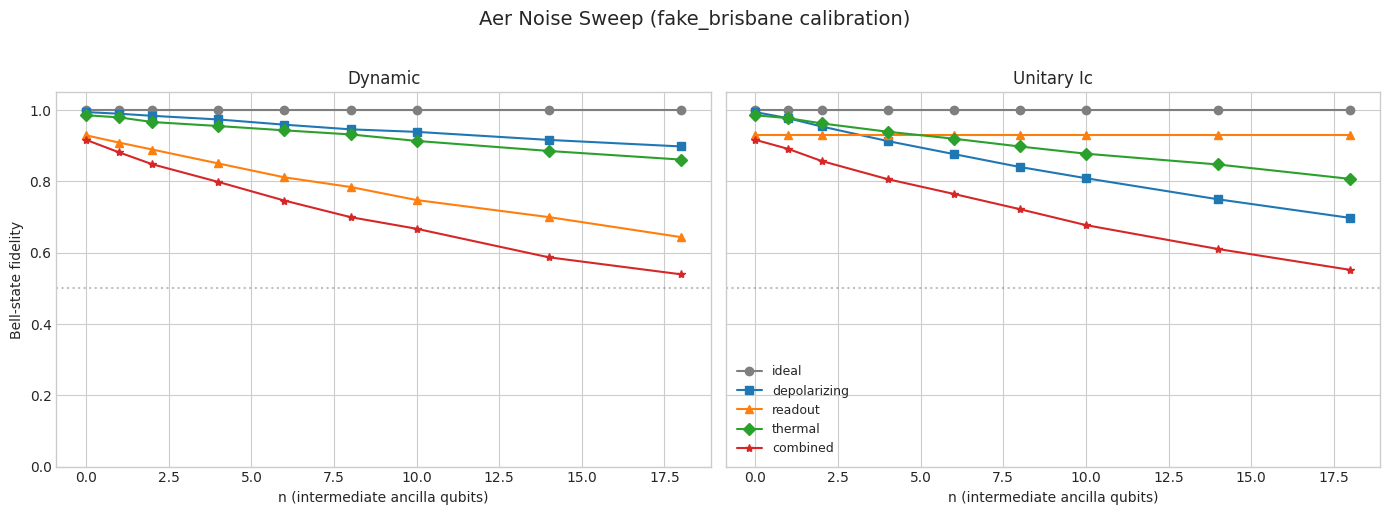

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
style_map = {"ideal":("o-","tab:gray"), "depolarizing":("s-","tab:blue"),
             "readout":("^-","tab:orange"), "thermal":("D-","tab:green"),
             "combined":("*-","tab:red")}
for ax, impl in zip(axes, IMPLEMENTATIONS):
    sub = results_df[results_df["implementation"] == impl]
    for nn, grp in sub.groupby("noise_model", sort=False):
        s,c = style_map.get(nn, ("o-","k"))
        ax.plot(grp["n_ancilla"], grp["fidelity"], s, color=c, label=nn, markersize=6)
    ax.set_xlabel("n (intermediate ancilla qubits)"); ax.set_title(impl.replace("_"," ").title())
    ax.set_ylim(0, 1.05); ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
axes[0].set_ylabel("Bell-state fidelity"); axes[1].legend(loc="best", fontsize=9)
fig.suptitle(f"Aer Noise Sweep ({backend_ref.name} calibration)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [13]:
max_n = max(SIM_DISTANCES)
single = results_df[results_df["noise_model"].isin(["depolarizing","readout","thermal"])]
at_max = single[single["n_ancilla"]==max_n].sort_values(["implementation","infidelity"], ascending=[True,False])
print(f"=== Dominant noise at n={max_n} ({backend_ref.name}) ===\n")
for impl in IMPLEMENTATIONS:
    row = at_max[at_max["implementation"]==impl].iloc[0]
    print(f"  {impl:12s}: {row.noise_model} (infidelity={row.infidelity:.4f})")

=== Dominant noise at n=18 (fake_brisbane) ===

  dynamic     : readout (infidelity=0.3562)
  unitary_ic  : depolarizing (infidelity=0.3024)


## Part 4 — Analytical Error Budget (Table I)

> **이제 선택한 하드웨어 스펙이 반영된 $\lambda$ 값을 사용합니다.**

| Implementation | $t_{\text{idle}}$ | $N_{\text{CNOT}}$ | $N_{\text{meas}}$ | 2Q depth |
|---|---|---|---|---|
| **Unitary Ic** | 0 | $4n+1$ | $n$ | $2n+1$ |
| **Dynamic** | $2\mu+2$ | $n+1$ | $2n$ | $2+\mu$ |

Crossover condition: $\lambda_{\text{meas}} < 3\lambda_{\text{CNOT}}$

In [14]:
def table_i_resources(n, impl, mu):
    if impl == "unitary_ic":
        return {"t_idle": 0.0, "N_CNOT": 4*n+1, "N_meas": n, "depth_2q": 2*n+1}
    elif impl == "dynamic":
        return {"t_idle": 2*mu+2, "N_CNOT": n+1, "N_meas": 2*n, "depth_2q": 2+mu}
    raise ValueError(impl)

def compute_lambda_tot(resources, params):
    return (resources["t_idle"] * params["lambda_idle"]
          + resources["N_CNOT"] * params["lambda_cnot"]
          + resources["N_meas"] * params["lambda_meas"])

# ==================================================================
# Build budget with BOTH reference and calibrated parameters
# ==================================================================
budget_rows = []
for label, params in [("reference (paper)", DEFAULT_BUDGET_PARAMS),
                      (f"calibrated ({backend_ref.name})", CALIBRATED_BUDGET)]:
    for impl in IMPLEMENTATIONS:
        for n in BUDGET_DISTANCES:
            res = table_i_resources(n, impl, params["mu"])
            lam = compute_lambda_tot(res, params)
            budget_rows.append({
                "param_source": label,
                "implementation": impl,
                "n_ancilla": n,
                **res,
                "lambda_idle_term":  res["t_idle"] * params["lambda_idle"],
                "lambda_cnot_term":  res["N_CNOT"] * params["lambda_cnot"],
                "lambda_meas_term":  res["N_meas"] * params["lambda_meas"],
                "lambda_total": lam,
                "F_lower_bound": np.exp(-lam),
            })

budget_df = pd.DataFrame(budget_rows)

# Crossover for calibrated params
cal_pivot = budget_df[budget_df["param_source"].str.contains("calibrated")].pivot(
    index="n_ancilla", columns="implementation", values="F_lower_bound").reset_index()
cal_pivot["dynamic_wins"] = cal_pivot["dynamic"] > cal_pivot["unitary_ic"]
cross_cal = cal_pivot[cal_pivot["dynamic_wins"]]
crossover_cal = None if cross_cal.empty else int(cross_cal.iloc[0]["n_ancilla"])

# Crossover for reference params
ref_pivot = budget_df[budget_df["param_source"].str.contains("reference")].pivot(
    index="n_ancilla", columns="implementation", values="F_lower_bound").reset_index()
ref_pivot["dynamic_wins"] = ref_pivot["dynamic"] > ref_pivot["unitary_ic"]
cross_ref = ref_pivot[ref_pivot["dynamic_wins"]]
crossover_ref = None if cross_ref.empty else int(cross_ref.iloc[0]["n_ancilla"])

print(f"=== Error Budget Summary ===")
print(f"  Total lambda reference:   {budget_df[budget_df['param_source'].str.contains('reference')]['lambda_total'].max():.6f}")
print(f"  Total lambda calibrated:  {budget_df[budget_df['param_source'].str.contains('calibrated')]['lambda_total'].max():.6f}")
print(f"  Reference lambda_idle={DEFAULT_BUDGET_PARAMS['lambda_idle']:.6f}, lambda_cnot={DEFAULT_BUDGET_PARAMS['lambda_cnot']:.6f}, lambda_meas={DEFAULT_BUDGET_PARAMS['lambda_meas']:.6f}")
print(f"  Calibrated lambda_idle={lambda_idle_cal:.6f}, lambda_cnot={lambda_cnot_cal:.6f}, lambda_meas={lambda_meas_cal:.6f}")
print(f"  Reference params:   crossover at n = {crossover_ref}")
print(f"  Calibrated params:  crossover at n = {crossover_cal}  ({backend_ref.name})")
print(f"\n  Calibrated: lambda_meas={lambda_meas_cal:.5f}, 3*lambda_CNOT={3*lambda_cnot_cal:.5f}")
print(f"  -> crossover condition met: {lambda_meas_cal < 3*lambda_cnot_cal}")

=== Error Budget Summary ===
  Total lambda reference:   5.520000
  Total lambda calibrated:  3.103496
  Reference lambda_idle=0.030000, lambda_cnot=0.020000, lambda_meas=0.030000
  Calibrated lambda_idle=0.003622, lambda_cnot=0.009696, lambda_meas=0.023092
  Reference params:   crossover at n = 10
  Calibrated params:  crossover at n = 5  (fake_brisbane)

  Calibrated: lambda_meas=0.02309, 3*lambda_CNOT=0.02909
  -> crossover condition met: True


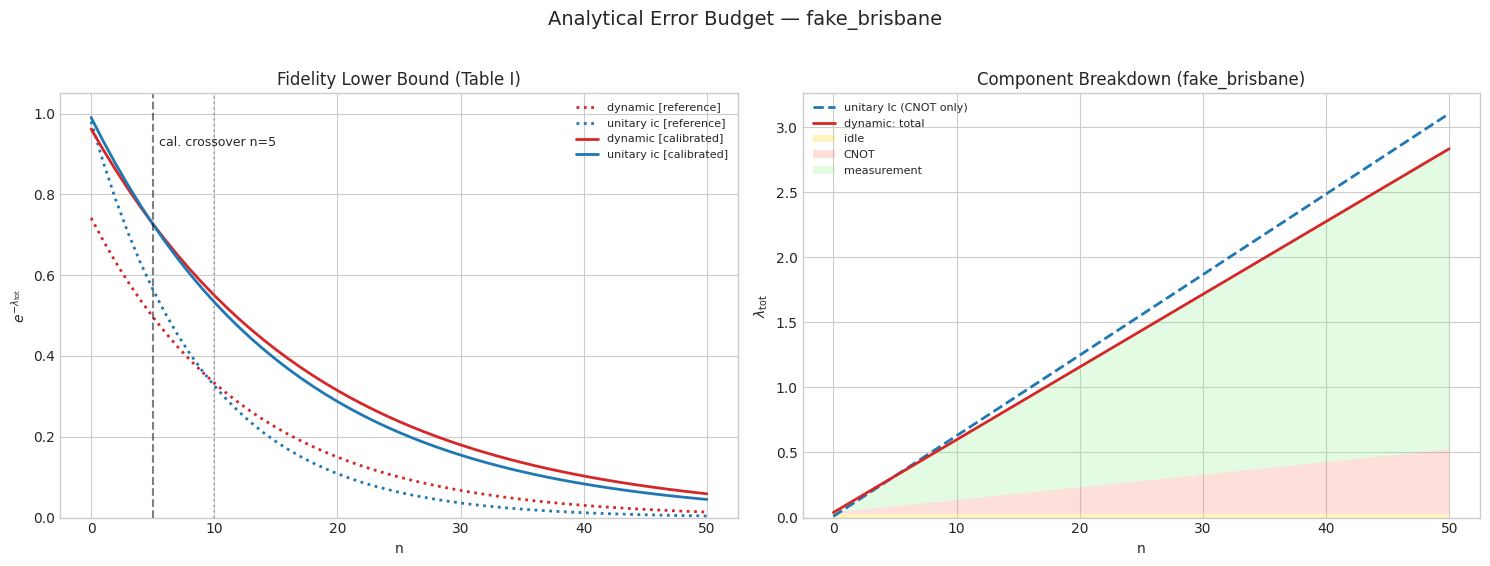

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Left: Fidelity lower bound ---
ax = axes[0]
colors = {"dynamic": "tab:red", "unitary_ic": "tab:blue"}
for src_label, ls in [("reference (paper)", ":"), (f"calibrated ({backend_ref.name})", "-")]:
    sub = budget_df[budget_df["param_source"] == src_label]
    for impl in IMPLEMENTATIONS:
        g = sub[sub["implementation"] == impl]
        label = f"{impl.replace('_',' ')} [{src_label.split('(')[0].strip()}]"
        ax.plot(g["n_ancilla"], g["F_lower_bound"], ls, color=colors[impl], lw=2, label=label)

ax.set_xlabel("n"); ax.set_ylabel(r"$e^{-\lambda_{\mathrm{tot}}}$")
ax.set_ylim(0, 1.05); ax.set_title(f"Fidelity Lower Bound (Table I)")
ax.legend(fontsize=8)
if crossover_cal is not None:
    ax.axvline(crossover_cal, color="k", ls="--", alpha=0.5)
    ax.text(crossover_cal+0.5, 0.92, f"cal. crossover n={crossover_cal}", fontsize=9)
if crossover_ref is not None:
    ax.axvline(crossover_ref, color="gray", ls=":", alpha=0.5)

# --- Right: Component breakdown (calibrated only) ---
ax = axes[1]
cal_budget = budget_df[budget_df["param_source"].str.contains("calibrated")]
dyn = cal_budget[cal_budget["implementation"]=="dynamic"]
uni = cal_budget[cal_budget["implementation"]=="unitary_ic"]

ax.plot(uni["n_ancilla"], uni["lambda_total"], "--", color="tab:blue", lw=2, label="unitary Ic (CNOT only)")
ax.plot(dyn["n_ancilla"], dyn["lambda_total"], "-", color="tab:red", lw=2, label="dynamic: total")
ax.stackplot(dyn["n_ancilla"],
             dyn["lambda_idle_term"], dyn["lambda_cnot_term"], dyn["lambda_meas_term"],
             labels=["idle", "CNOT", "measurement"], alpha=0.25,
             colors=["gold","salmon","lightgreen"])
ax.set_xlabel("n"); ax.set_ylabel(r"$\lambda_{\mathrm{tot}}$")
ax.set_title(f"Component Breakdown ({backend_ref.name})")
ax.legend(loc="upper left", fontsize=8)

fig.suptitle(f"Analytical Error Budget — {backend_ref.name}", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Part 5 — Fake-Backend Transpiled Simulation

선택한 Fake backend의 coupling map 위에 **transpile**하고, chain에 해당하는 큐비트만 포함한 **제한된 noise model**로 시뮬레이션합니다.

> `AerSimulator.from_backend()`을 사용하면 127큐비트 전체를 시뮬레이션하므로 커널이 크래시합니다.
> 대신 `build_selective_noise_for_chain()`으로 chain 큐비트만의 noise model을 구성합니다.

In [16]:
# ---- Topology helpers ----

# ============================================================
# Error-aware chain finder
# ============================================================

BAD_QUBITS = {19, 35}

READOUT_ERR_LIMIT = 0.03      # 필요하면 0.05 정도로 완화
TWOQ_ERR_LIMIT = 0.03         # 필요하면 0.05 정도로 완화
CHAIN_BEAM_WIDTH = 5000


def _backend_edges_undirected(backend):
    """Return undirected coupling edges."""
    edges = backend.coupling_map.get_edges()
    undirected = set()
    for u, v in edges:
        if u != v:
            undirected.add(tuple(sorted((int(u), int(v)))))
    return sorted(undirected)


def _readout_error(backend, q):
    """Get readout error from BackendV2 target if possible."""
    target = getattr(backend, "target", None)

    if target is not None:
        try:
            if "measure" in target.operation_names:
                props = target["measure"].get((q,), None)
                if props is not None and props.error is not None:
                    return float(props.error)
        except Exception:
            pass

    try:
        props = backend.properties()
        return float(props.readout_error(q))
    except Exception:
        return 0.0


def _twoq_error(backend, u, v):
    """Get two-qubit gate error for CZ/ECR/CX."""
    target = getattr(backend, "target", None)

    if target is not None:
        for gate in ["cz", "ecr", "cx"]:
            try:
                if gate not in target.operation_names:
                    continue

                gate_props = target[gate]

                for pair in [(u, v), (v, u)]:
                    props = gate_props.get(pair, None)
                    if props is not None and props.error is not None:
                        return float(props.error)

            except Exception:
                pass

    try:
        props = backend.properties()
        for gate in ["cz", "ecr", "cx"]:
            for pair in [(u, v), (v, u)]:
                try:
                    return float(props.gate_error(gate, pair))
                except Exception:
                    pass
    except Exception:
        pass

    return 0.0


def validate_chain(backend, chain):
    """Check that the chain is physically connected and has no duplicates."""
    edges = set(_backend_edges_undirected(backend))

    if len(chain) != len(set(chain)):
        raise ValueError(f"Chain has duplicated qubits: {chain}")

    for a, b in zip(chain[:-1], chain[1:]):
        if tuple(sorted((a, b))) not in edges:
            raise ValueError(f"Invalid chain edge: {a} -- {b}")

    return True


def summarize_chain_quality(backend, chain):
    q_errors = [_readout_error(backend, q) for q in chain]
    e_errors = [
        _twoq_error(backend, a, b)
        for a, b in zip(chain[:-1], chain[1:])
    ]

    print(f"chain length      = {len(chain)}")
    print(f"chain             = {chain}")
    print(f"max readout error = {max(q_errors):.4e}")
    print(f"avg readout error = {np.mean(q_errors):.4e}")

    if e_errors:
        print(f"max twoq error    = {max(e_errors):.4e}")
        print(f"avg twoq error    = {np.mean(e_errors):.4e}")

    bad_inside = sorted(set(chain) & BAD_QUBITS)
    print(f"bad qubits inside = {bad_inside}")


def find_error_aware_chain(
    backend,
    length,
    avoid_qubits=None,
    readout_err_limit=READOUT_ERR_LIMIT,
    twoq_err_limit=TWOQ_ERR_LIMIT,
    beam_width=CHAIN_BEAM_WIDTH,
):
    """
    Find a connected physical-qubit chain of given length while avoiding bad qubits.

    This is a beam-search heuristic:
    - removes manually avoided qubits such as 19 and 35
    - removes qubits with high readout error
    - removes edges with high two-qubit error
    - searches for a low-error connected path
    """
    avoid_qubits = set(avoid_qubits or [])

    edges = _backend_edges_undirected(backend)

    q_err = {
        q: _readout_error(backend, q)
        for q in range(backend.num_qubits)
    }

    e_err = {
        edge: _twoq_error(backend, edge[0], edge[1])
        for edge in edges
    }

    # Automatically avoid high-readout qubits.
    for q, err in q_err.items():
        if err > readout_err_limit:
            avoid_qubits.add(q)

    neighbors = {q: set() for q in range(backend.num_qubits)}

    for u, v in edges:
        if u in avoid_qubits or v in avoid_qubits:
            continue

        if e_err[(u, v)] > twoq_err_limit:
            continue

        neighbors[u].add(v)
        neighbors[v].add(u)

    usable_qubits = [
        q for q in range(backend.num_qubits)
        if q not in avoid_qubits and len(neighbors[q]) > 0
    ]

    if length > len(usable_qubits):
        raise ValueError(
            f"Need chain length {length}, but only {len(usable_qubits)} usable qubits remain. "
            f"Relax READOUT_ERR_LIMIT or TWOQ_ERR_LIMIT."
        )

    # Initial beam: start from every usable qubit.
    beam = [
        (q_err[q], (q,))
        for q in usable_qubits
    ]

    beam.sort(key=lambda x: x[0])
    beam = beam[:beam_width]

    for _ in range(1, length):
        candidates = []

        for score, path in beam:
            last = path[-1]
            used = set(path)

            next_qubits = sorted(
                neighbors[last],
                key=lambda nb: (
                    5.0 * e_err[tuple(sorted((last, nb)))]
                    + q_err[nb]
                )
            )

            for nb in next_qubits:
                if nb in used:
                    continue

                edge = tuple(sorted((last, nb)))

                new_score = (
                    score
                    + q_err[nb]
                    + 5.0 * e_err[edge]
                )

                candidates.append((new_score, path + (nb,)))

        if not candidates:
            raise ValueError(
                f"Could not find chain of length {length}. "
                f"Try increasing CHAIN_BEAM_WIDTH or relaxing error thresholds."
            )

        candidates.sort(key=lambda x: x[0])
        beam = candidates[:beam_width]

    best_chain = list(beam[0][1])
    validate_chain(backend, best_chain)
    return best_chain


# ---- Chain-aware noise model ----
#
# Uses MEDIAN calibration properties of the specific qubit chain,
# applied uniformly via add_all_qubit_quantum_error.
# This avoids:
#   1) 127-qubit simulation crash (no coupling_map, no transpile)
#   2) "Kraus is empty" error (no per-qubit compose edge cases)
# While still reflecting chain-specific hardware quality.

def build_chain_noise_model(backend, chain,
                            thermal=True, depol=True, readout=True):
    """Build noise model using chain's median HW properties.

    Circuits run on logical qubits 0..len(chain)-1.
    Noise is applied uniformly (all-qubit) using the median T1, T2,
    gate error, and readout error of the physical qubits on the chain.
    """
    nm = NoiseModel()
    target = backend.target
    native_2q = next(
        (g for g in ["ecr", "cx", "cz"] if g in target.operation_names), None
    )

    # ---- Collect calibration data from chain qubits ----
    chain_t1, chain_t2 = [], []
    chain_1q_err, chain_1q_dur = [], []
    chain_2q_err, chain_2q_dur = [], []
    chain_meas_err, chain_meas_dur = [], []

    for phys_q in chain:
        qp = target.qubit_properties[phys_q]
        if qp and qp.t1 and qp.t1 > 0:
            chain_t1.append(qp.t1)
        if qp and qp.t2 and qp.t2 > 0:
            chain_t2.append(min(qp.t2, 2 * qp.t1 if qp.t1 else qp.t2))
        for gn in ["sx", "x"]:
            if gn not in target.operation_names:
                continue
            p = target[gn].get((phys_q,))
            if p and p.error and p.error > 0:
                chain_1q_err.append(p.error)
            if p and p.duration and p.duration > 0:
                chain_1q_dur.append(p.duration)
        if "measure" in target.operation_names:
            p = target["measure"].get((phys_q,))
            if p and p.error and p.error > 0:
                chain_meas_err.append(p.error)
            if p and p.duration and p.duration > 0:
                chain_meas_dur.append(p.duration)

    if native_2q:
        for i in range(len(chain) - 1):
            for pair in [(chain[i], chain[i+1]), (chain[i+1], chain[i])]:
                p = target[native_2q].get(pair)
                if not p:
                    continue
                if p.error and p.error > 0:
                    chain_2q_err.append(p.error)
                if p.duration and p.duration > 0:
                    chain_2q_dur.append(p.duration)

    # ---- Compute medians ----
    med_t1       = median(chain_t1)       if chain_t1       else 100e-6
    med_t2       = median(chain_t2)       if chain_t2       else 50e-6
    med_1q_err   = median(chain_1q_err)   if chain_1q_err   else 1e-4
    med_2q_err   = median(chain_2q_err)   if chain_2q_err   else 0.01
    med_2q_dur   = median(chain_2q_dur)   if chain_2q_dur   else 300e-9
    med_meas_err = median(chain_meas_err) if chain_meas_err else 0.02
    med_meas_dur = median(chain_meas_dur) if chain_meas_dur else 800e-9

    # ---- Build noise ----
    # 1Q gates
    if depol and med_1q_err > 1e-15:
        nm.add_all_qubit_quantum_error(
            depolarizing_error(min(med_1q_err, 0.75 - 1e-10), 1),
            ["x", "z", "h", "sx", "sdg", "id", "s"])

    # 2Q gates
    chs_2q = []
    if thermal and med_2q_dur > 1e-15:
        e_single = thermal_relaxation_error(med_t1, med_t2, med_2q_dur)
        chs_2q.append(e_single.tensor(e_single))
    if depol and med_2q_err > 1e-15:
        chs_2q.append(depolarizing_error(min(med_2q_err, 15/16 - 1e-10), 2))
    if chs_2q:
        err_2q = chs_2q[0]
        for c in chs_2q[1:]:
            err_2q = err_2q.compose(c)
        nm.add_all_qubit_quantum_error(err_2q, ["cx"])

    # Measurement & reset thermal relaxation
    if thermal and med_meas_dur > 1e-15:
        meas_thermal = thermal_relaxation_error(med_t1, med_t2, med_meas_dur)
        nm.add_all_qubit_quantum_error(meas_thermal, ["measure"])
        nm.add_all_qubit_quantum_error(meas_thermal, ["reset"])

    # Readout error
    if readout and med_meas_err > 1e-15:
        p = min(med_meas_err, 0.5)
        nm.add_all_qubit_readout_error(
            ReadoutError([[1 - p, p], [p, 1 - p]]))

    return nm


# ---- Fake-backend sweep ----

FAKE_SIM_DISTANCES = [0, 1, 2, 4, 6, 8, 10, 12]

def run_fake_backend_sweep(backend, distances, shots=2048):
    rows = []
    for impl in IMPLEMENTATIONS:
        for n in distances:
            try:
                chain = find_error_aware_chain(
                backend,
                n+2,
                avoid_qubits=BAD_QUBITS,
                readout_err_limit=READOUT_ERR_LIMIT,
                twoq_err_limit=TWOQ_ERR_LIMIT,
                beam_width=CHAIN_BEAM_WIDTH,
            )
            except ValueError:
                print(f"  skip {impl} n={n}: chain too long")
                continue

            nm = build_chain_noise_model(backend, chain,
                                         thermal=True, depol=True, readout=True)
            sim = AerSimulator(noise_model=nm, seed_simulator=SEED)

            circs = build_bell_test_circuits(n, impl)
            cl = [sim.run(c, shots=shots).result().get_counts() for c in circs]
            F = bell_fidelity(cl[0], cl[1], cl[2])

            res = table_i_resources(n, impl, CALIBRATED_BUDGET["mu"])
            lam = compute_lambda_tot(res, CALIBRATED_BUDGET)

            rows.append({
                "implementation": impl,
                "n_ancilla": n,
                "fidelity_sim": F,
                "F_budget": np.exp(-lam),
                "lambda_total": lam,
            })
            print(f"  {impl:12s} n={n:2d}  F_sim={F:.4f}  F_budget={np.exp(-lam):.4f}")

        gc.collect()

    return pd.DataFrame(rows)


print(f"Running sweep on {backend_ref.name} (chain-aware noise)...")
fake_results = run_fake_backend_sweep(backend_ref, FAKE_SIM_DISTANCES)
print(f"Done. {len(fake_results)} points.")

Running sweep on fake_brisbane (chain-aware noise)...
  dynamic      n= 0  F_sim=0.9453  F_budget=0.9619
  dynamic      n= 1  F_sim=0.9265  F_budget=0.9096
  dynamic      n= 2  F_sim=0.8940  F_budget=0.8601
  dynamic      n= 4  F_sim=0.8440  F_budget=0.7692
  dynamic      n= 6  F_sim=0.8071  F_budget=0.6879
  dynamic      n= 8  F_sim=0.7786  F_budget=0.6151
  dynamic      n=10  F_sim=0.7190  F_budget=0.5501
  dynamic      n=12  F_sim=0.6838  F_budget=0.4919
  unitary_ic   n= 0  F_sim=0.9453  F_budget=0.9904
  unitary_ic   n= 1  F_sim=0.9238  F_budget=0.9309
  unitary_ic   n= 2  F_sim=0.8848  F_budget=0.8751
  unitary_ic   n= 4  F_sim=0.8506  F_budget=0.7732
  unitary_ic   n= 6  F_sim=0.8015  F_budget=0.6832
  unitary_ic   n= 8  F_sim=0.7590  F_budget=0.6037
  unitary_ic   n=10  F_sim=0.7144  F_budget=0.5334
  unitary_ic   n=12  F_sim=0.6509  F_budget=0.4713
Done. 16 points.


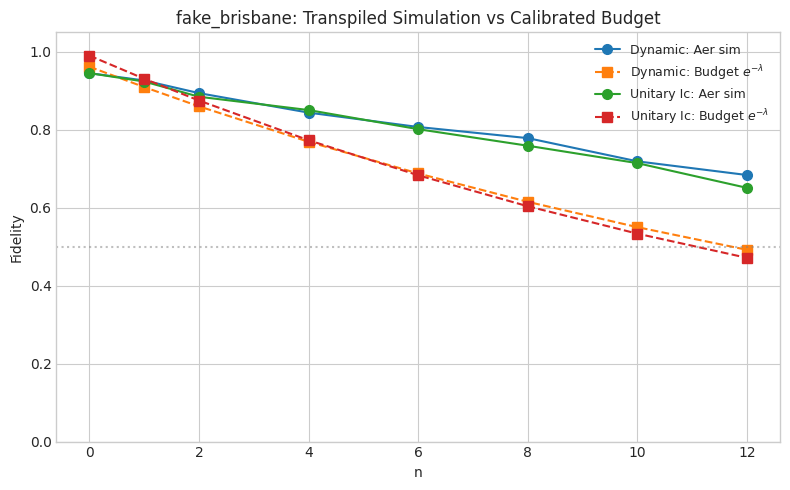

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

for impl in IMPLEMENTATIONS:
    sub = fake_results[fake_results["implementation"] == impl].sort_values("n_ancilla")
    impl_label = impl.replace("_", " ").title()

    # Aer simulation
    ax.plot(
        sub["n_ancilla"],
        sub["fidelity_sim"],
        "o-",
        markersize=7,
        label=f"{impl_label}: Aer sim"
    )

    # Calibrated budget
    ax.plot(
        sub["n_ancilla"],
        sub["F_budget"],
        "s--",
        markersize=7,
        label=rf"{impl_label}: Budget $e^{{-\lambda}}$"
    )

ax.set_xlabel("n")
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
ax.set_title(f"{backend_ref.name}: Transpiled Simulation vs Calibrated Budget")
ax.legend(fontsize=9)

plt.tight_layout()

fig.savefig(
    "figures/transpiled_sim_vs_budget.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

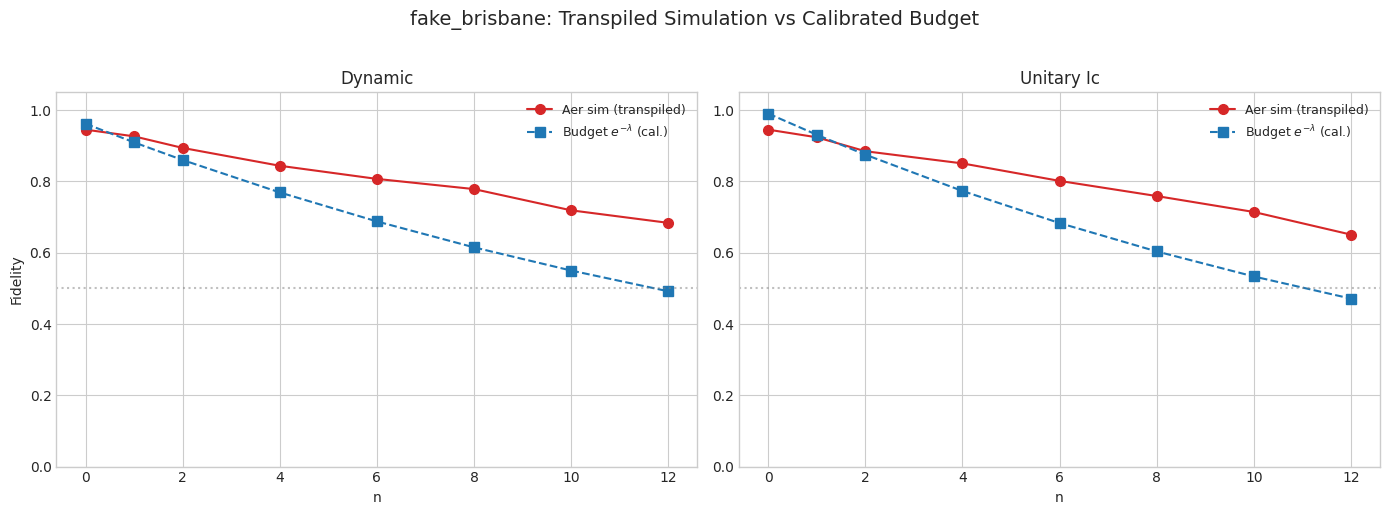

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, impl in zip(axes, IMPLEMENTATIONS):
    sub = fake_results[fake_results["implementation"]==impl]
    ax.plot(sub["n_ancilla"], sub["fidelity_sim"], "o-", color="tab:red", markersize=7, label="Aer sim (transpiled)")
    ax.plot(sub["n_ancilla"], sub["F_budget"], "s--", color="tab:blue", markersize=7, label=r"Budget $e^{-\lambda}$ (cal.)")
    ax.set_xlabel("n"); ax.set_title(impl.replace("_"," ").title())
    ax.set_ylim(0, 1.05); ax.axhline(0.5, color="gray", ls=":", alpha=0.5); ax.legend(fontsize=9)
axes[0].set_ylabel("Fidelity")
fig.suptitle(f"{backend_ref.name}: Transpiled Simulation vs Calibrated Budget", fontsize=14, y=1.02)
plt.tight_layout(); 
fig.savefig(
    "figures/transpiled_sim_vs_budget_subfigure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Per-Noise-Source Breakdown on Fake Backend

In [19]:
configs = {
    "thermal only":    {"thermal": True,  "depol": False, "readout": False},
    "gate error only": {"thermal": False, "depol": True,  "readout": False},
    "readout only":    {"thermal": False, "depol": False, "readout": True},
    "all combined":    {"thermal": True,  "depol": True,  "readout": True},
}

BD = [0, 2, 4, 6, 8, 10]
bd_rows = []

for lbl, cfg in configs.items():
    for n in BD:
        try:
            chain = find_error_aware_chain(
                backend_ref,
                n+2,
                avoid_qubits=BAD_QUBITS,
                readout_err_limit=READOUT_ERR_LIMIT,
                twoq_err_limit=TWOQ_ERR_LIMIT,
                beam_width=CHAIN_BEAM_WIDTH,
            )
        except ValueError:
            continue

        nm = build_chain_noise_model(backend_ref, chain, **cfg)
        sim = AerSimulator(noise_model=nm, seed_simulator=SEED)

        circs = build_bell_test_circuits(n, "dynamic")
        cl = [sim.run(c, shots=2048).result().get_counts() for c in circs]
        F = bell_fidelity(cl[0], cl[1], cl[2])

        bd_rows.append({
            "noise_source": lbl,
            "n_ancilla": n,
            "fidelity": F,
            "infidelity": 1 - F,
        })
        print(f"  {lbl:20s} n={n:2d}  F={F:.4f}")

    gc.collect()

breakdown_df = pd.DataFrame(bd_rows)
print("Done.")

  thermal only         n= 0  F=0.9834
  thermal only         n= 2  F=0.9700
  thermal only         n= 4  F=0.9683
  thermal only         n= 6  F=0.9451
  thermal only         n= 8  F=0.9287
  thermal only         n=10  F=0.9180
  gate error only      n= 0  F=0.9956
  gate error only      n= 2  F=0.9871
  gate error only      n= 4  F=0.9810
  gate error only      n= 6  F=0.9634
  gate error only      n= 8  F=0.9536
  gate error only      n=10  F=0.9456
  readout only         n= 0  F=0.9692
  readout only         n= 2  F=0.9270
  readout only         n= 4  F=0.8755
  readout only         n= 6  F=0.8772
  readout only         n= 8  F=0.8555
  readout only         n=10  F=0.8101
  all combined         n= 0  F=0.9453
  all combined         n= 2  F=0.8940
  all combined         n= 4  F=0.8440
  all combined         n= 6  F=0.8071
  all combined         n= 8  F=0.7786
  all combined         n=10  F=0.7190
Done.


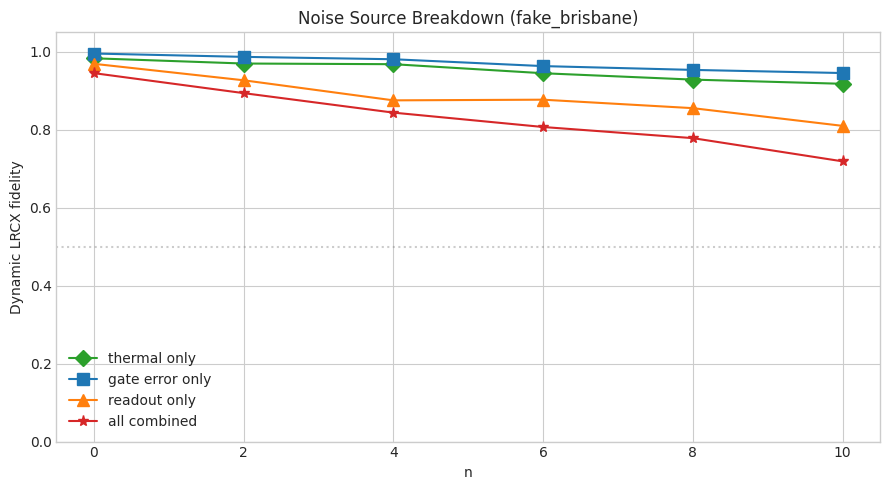


Dominant noise at n=10: readout only (infidelity=0.1899)


In [20]:
fig, ax = plt.subplots(figsize=(9,5))
sty = {"thermal only":("D-","tab:green"), "gate error only":("s-","tab:blue"),
       "readout only":("^-","tab:orange"), "all combined":("*-","tab:red")}
for lbl, grp in breakdown_df.groupby("noise_source", sort=False):
    s,c = sty.get(lbl,("o-","k"))
    ax.plot(grp["n_ancilla"], grp["fidelity"], s, color=c, label=lbl, markersize=8)
ax.set_xlabel("n"); ax.set_ylabel("Dynamic LRCX fidelity")
ax.set_title(f"Noise Source Breakdown ({backend_ref.name})"); ax.set_ylim(0,1.05)
ax.axhline(0.5, color="gray", ls=":", alpha=0.4); ax.legend(fontsize=10)
plt.tight_layout();
fig.savefig(
    "figures/Noise_Source_Breakdown.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

mx = max(BD)
at_mx = breakdown_df[(breakdown_df["n_ancilla"]==mx)&(breakdown_df["noise_source"]!="all combined")]
at_mx = at_mx.sort_values("infidelity", ascending=False)
print(f"\nDominant noise at n={mx}: {at_mx.iloc[0]['noise_source']} (infidelity={at_mx.iloc[0]['infidelity']:.4f})")

## Part 6 — Least-Busy Real Hardware Submission

`USE_REAL_BACKEND = True`이면 IBM Quantum에서 현재 접근 가능한 least-busy 실제 QPU를 선택합니다.  
아래 Part 6b 셀은 **Aer simulation이 아니라 실제 하드웨어 job을 제출**하고, Runtime Sampler 결과의 `cr` register counts로 Bell fidelity를 계산합니다.

> 실제 QPU queue 시간이 걸릴 수 있으므로, 처음에는 `REAL_HW_DISTANCES`와 `REAL_HW_SHOTS`를 작게 두었습니다. 더 촘촘한 비교가 필요하면 값을 늘리면 됩니다.


In [21]:
# ============================================================
# Part 6 — Select least-busy real hardware backend + calibration
# ============================================================

if USE_REAL_BACKEND:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

    service = QiskitRuntimeService()

    # Dynamic LRCX uses mid-circuit measurement, reset, and feed-forward.
    # Therefore we request a real, operational backend that supports dynamic circuits.
    real_backend = service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=127,
        dynamic_circuits=True,
    )

    print(f"Least-busy real backend selected: {real_backend.name}")
    print(f"Qubits: {real_backend.num_qubits}")
    print("This backend will be used for actual QPU job submission in Part 6b.")

    _t2q = median_2q_duration(real_backend)
    _ge = median_2q_error(real_backend)
    _ro = median_readout_err(real_backend)
    _t1r, _t2r = median_t1_t2_us(real_backend)
    _t_meas_ns = median_meas_time_ns(real_backend)

    _t2q_ns = _t2q * 1e9
    _t1r_ns = _t1r * 1e3
    _t2r_ns = min(_t2r * 1e3, 2 * _t1r_ns)

    REAL_BUDGET = {
        "mu": (_t_meas_ns + FEEDFORWARD_TIME_NS) / _t2q_ns,
        "lambda_idle": _idle_lambda_per_cnot_time(_t1r_ns, _t2r_ns, _t2q_ns),
        "lambda_cnot": _cnot_lambda_per_operation(_ge, 4),
        "lambda_meas": _error_probability_to_lambda(_ro),
    }

    real_cal_df = pd.DataFrame([{
        "backend": real_backend.name,
        "qubits": real_backend.num_qubits,
        "T1 (us)": round(_t1r, 1),
        "T2 (us)": round(_t2r, 1),
        "t_2q (ns)": round(_t2q_ns, 1),
        "t_meas (ns)": round(_t_meas_ns, 1),
        "gate_err": round(_ge, 5),
        "readout_err": round(_ro, 5),
        **REAL_BUDGET,
        "3*lambda_CNOT": 3 * REAL_BUDGET["lambda_cnot"],
        "crossover met?": REAL_BUDGET["lambda_meas"] < 3 * REAL_BUDGET["lambda_cnot"],
    }])
    display(real_cal_df)

else:
    print("USE_REAL_BACKEND=False. No hardware job will be submitted.")
    real_backend = backend_ref
    REAL_BUDGET = CALIBRATED_BUDGET.copy()


Least-busy real backend selected: ibm_aachen
Qubits: 156
This backend will be used for actual QPU job submission in Part 6b.


,backend,qubits,T1 (us),T2 (us),t_2q (ns),t_meas (ns),gate_err,readout_err,mu,lambda_idle,lambda_cnot,lambda_meas,3*lambda_CNOT,crossover met?
0,ibm_aachen,156,220.8,242.8,68.0,2180.0,0.00164,0.00421,42.352941,0.000294,0.002055,0.00422,0.006164,True


## Part 6b — Actual QPU Run with Runtime Sampler

이 셀은 `least_busy`로 선택된 실제 IBM Quantum backend에 회로를 제출합니다.

- 각 `(implementation, n)`마다 `XX`, `YY`, `ZZ` 측정 회로 3개를 만듭니다.
- `generate_preset_pass_manager(..., backend=real_backend)`로 ISA 회로로 변환합니다.
- `SamplerV2(mode=real_backend)`로 실제 QPU job을 제출합니다.
- 결과 counts에서 Bell fidelity를 계산합니다.


In [22]:
# ============================================================
# Actual least-busy QPU submission
# ============================================================

# Use a small default set first because real QPU queue time can be long.
# For the full fake-backend sweep, change this to: REAL_HW_DISTANCES = FAKE_SIM_DISTANCES
REAL_HW_DISTANCES = [0, 1, 2, 4, 6, 11, 16, 21, 28, 35, 44, 55, 60]
REAL_HW_SHOTS = 1024
REAL_HW_OPT_LEVEL = 1

# Set this to False only if you want to prepare the circuits without submitting.
SUBMIT_REAL_HW_JOB = True


def _make_pass_manager_for_backend(backend, initial_layout=None, opt_level=1):
    """Compatibility wrapper for Qiskit versions with different import paths."""
    try:
        from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager as _gppm
    except Exception:
        from qiskit.transpiler import generate_preset_pass_manager as _gppm
    return _gppm(
        backend=backend,
        optimization_level=opt_level,
        initial_layout=initial_layout,
    )


def _job_id(job):
    jid = getattr(job, "job_id", None)
    return jid() if callable(jid) else jid


def _databin_keys(data):
    if hasattr(data, "keys"):
        try:
            return list(data.keys())
        except Exception:
            pass
    # DataBin often exposes registers as attributes.
    keys = []
    for name in dir(data):
        if name.startswith("_"):
            continue
        try:
            obj = getattr(data, name)
        except Exception:
            continue
        if hasattr(obj, "get_counts"):
            keys.append(name)
    return keys


def _counts_from_pub_result(pub_result, register_name="cr"):
    """Extract counts from the final 2-bit classical register.

    The Bell-test wrapper measures the two output qubits into the register named 'cr'.
    Dynamic circuits may also contain c1/c2 registers from mid-circuit measurements,
    so we intentionally read only 'cr'.
    """
    data = pub_result.data

    if hasattr(data, register_name):
        return getattr(data, register_name).get_counts()

    # If the transpiler/runtime renamed the register, fall back to any 2-bit register.
    for key in _databin_keys(data):
        bitarray = getattr(data, key)
        try:
            counts = bitarray.get_counts()
        except Exception:
            continue
        if counts and all(len(bitstr.replace(" ", "")) == 2 for bitstr in counts):
            print(f"Warning: using register '{key}' instead of '{register_name}'.")
            return counts

    raise RuntimeError(
        f"Could not find a 2-bit final-measurement register. Available registers: {_databin_keys(data)}"
    )


def prepare_real_hardware_circuits(backend, distances):
    """Build and transpile all Bell-test circuits for actual hardware execution."""
    isa_circuits = []
    metadata = []

    for impl in IMPLEMENTATIONS:
        for n in distances:
            logical_qubits = n + 2
            try:
                chain = find_error_aware_chain(
                    backend,
                    logical_qubits,
                    avoid_qubits=BAD_QUBITS,
                    readout_err_limit=READOUT_ERR_LIMIT,
                    twoq_err_limit=TWOQ_ERR_LIMIT,
                    beam_width=CHAIN_BEAM_WIDTH,
                )
            except Exception as exc:
                print(f"skip {impl} n={n}: could not find chain of length {logical_qubits}: {exc}")
                continue

            raw_circuits = build_bell_test_circuits(n, impl)
            pm = _make_pass_manager_for_backend(
                backend,
                initial_layout=chain,
                opt_level=REAL_HW_OPT_LEVEL,
            )
            transpiled = pm.run(raw_circuits)

            for basis, raw, isa in zip(BASES, raw_circuits, transpiled):
                isa_circuits.append(isa)
                metadata.append({
                    "backend": backend.name,
                    "implementation": impl,
                    "n_ancilla": n,
                    "basis": basis,
                    "physical_chain": chain,
                    "raw_depth": raw.depth(),
                    "isa_depth": isa.depth(),
                    "raw_size": raw.size(),
                    "isa_size": isa.size(),
                })

            print(
                f"prepared {impl:12s} n={n:2d}: "
                f"3 basis circuits, chain={chain}, "
                f"ISA depths={[c.depth() for c in transpiled]}"
            )

    return isa_circuits, pd.DataFrame(metadata)


def results_from_sampler_job(job, metadata_df, budget_params):
    """Convert Runtime Sampler result into one fidelity row per (implementation, n)."""
    sampler_result = job.result()
    counts_by_pub = []

    for idx, pub_result in enumerate(sampler_result):
        counts = _counts_from_pub_result(pub_result, register_name="cr")
        counts_by_pub.append(counts)

    rows = []
    grouped = metadata_df.reset_index().groupby(["implementation", "n_ancilla"], sort=False)

    for (impl, n), group in grouped:
        basis_counts = {}
        for _, meta in group.iterrows():
            basis_counts[meta["basis"]] = counts_by_pub[int(meta["index"])]

        missing = set(BASES) - set(basis_counts)
        if missing:
            raise RuntimeError(f"Missing basis results for {impl}, n={n}: {missing}")

        F_hw = bell_fidelity(
            basis_counts["XX"],
            basis_counts["YY"],
            basis_counts["ZZ"],
        )

        res = table_i_resources(int(n), impl, budget_params["mu"])
        lam = compute_lambda_tot(res, budget_params)

        rows.append({
            "backend": group["backend"].iloc[0],
            "job_id": _job_id(job),
            "implementation": impl,
            "n_ancilla": int(n),
            "shots": REAL_HW_SHOTS,
            "fidelity_hw": F_hw,
            "F_budget": np.exp(-lam),
            "lambda_total": lam,
            "chain": group["physical_chain"].iloc[0],
            "isa_depth_max": int(group["isa_depth"].max()),
            "isa_size_max": int(group["isa_size"].max()),
        })

    return pd.DataFrame(rows)


if USE_REAL_BACKEND:
    print(f"Preparing circuits for actual QPU backend: {real_backend.name}")
    real_hw_isa_circuits, real_hw_metadata = prepare_real_hardware_circuits(
        real_backend,
        REAL_HW_DISTANCES,
    )
    display(real_hw_metadata)

    if SUBMIT_REAL_HW_JOB:
        print(f"Submitting {len(real_hw_isa_circuits)} ISA circuits to {real_backend.name} ...")
        sampler = Sampler(mode=real_backend)
        real_hw_job = sampler.run(real_hw_isa_circuits, shots=REAL_HW_SHOTS)
        REAL_HW_JOB_ID = _job_id(real_hw_job)
        print(f"Submitted QPU job id: {REAL_HW_JOB_ID}")

        # This blocks until the hardware job completes, then computes fidelities.
        real_hw_results = results_from_sampler_job(real_hw_job, real_hw_metadata, REAL_BUDGET)
        display(real_hw_results)
    else:
        print("SUBMIT_REAL_HW_JOB=False. Circuits were prepared but not submitted.")
        real_hw_results = pd.DataFrame()
else:
    print("USE_REAL_BACKEND=False. No actual QPU job submitted.")
    real_hw_isa_circuits = []
    real_hw_metadata = pd.DataFrame()
    real_hw_results = pd.DataFrame()


Preparing circuits for actual QPU backend: ibm_aachen


prepared dynamic      n= 0: 3 basis circuits, chain=[100, 101], ISA depths=[11, 10, 8]
prepared dynamic      n= 1: 3 basis circuits, chain=[100, 101, 116], ISA depths=[17, 16, 14]
prepared dynamic      n= 2: 3 basis circuits, chain=[84, 83, 96, 103], ISA depths=[17, 16, 14]
prepared dynamic      n= 4: 3 basis circuits, chain=[100, 101, 102, 103, 96, 83], ISA depths=[17, 16, 14]
prepared dynamic      n= 6: 3 basis circuits, chain=[100, 101, 102, 103, 96, 83, 82, 81], ISA depths=[17, 16, 14]
prepared dynamic      n=11: 3 basis circuits, chain=[100, 101, 102, 103, 96, 83, 84, 85, 86, 87, 97, 107, 108], ISA depths=[17, 16, 14]
prepared dynamic      n=16: 3 basis circuits, chain=[84, 83, 96, 103, 104, 105, 106, 107, 97, 87, 86, 85, 77, 65, 64, 63, 62, 61], ISA depths=[17, 16, 14]
prepared dynamic      n=21: 3 basis circuits, chain=[40, 41, 42, 43, 56, 63, 64, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 80], ISA depths=[17, 16, 14]
prepared dynamic      n=28: 3 basis cir

,backend,implementation,n_ancilla,basis,physical_chain,raw_depth,isa_depth,raw_size,isa_size
0,ibm_aachen,dynamic,0,XX,"[100, 101]",4,11,6,18
1,ibm_aachen,dynamic,0,YY,"[100, 101]",5,10,8,16
2,ibm_aachen,dynamic,0,ZZ,"[100, 101]",3,8,4,12
3,ibm_aachen,dynamic,1,XX,"[100, 101, 116]",8,17,11,31
4,ibm_aachen,dynamic,1,YY,"[100, 101, 116]",9,16,13,29
...,...,...,...,...,...,...,...,...,...
73,ibm_aachen,unitary_ic,55,YY,"[95, 94, 93, 79, 73, 74, 75, 59, 55, 54, 53, 3...",116,302,228,1556
74,ibm_aachen,unitary_ic,55,ZZ,"[95, 94, 93, 79, 73, 74, 75, 59, 55, 54, 53, 3...",114,300,224,1552
75,ibm_aachen,unitary_ic,60,XX,"[95, 94, 93, 79, 73, 74, 75, 59, 55, 54, 53, 3...",124,323,246,1698
76,ibm_aachen,unitary_ic,60,YY,"[95, 94, 93, 79, 73, 74, 75, 59, 55, 54, 53, 3...",125,322,248,1696


Submitting 78 ISA circuits to ibm_aachen ...
Submitted QPU job id: d91m6q3fbr7s73fk57mg


,backend,job_id,implementation,n_ancilla,shots,fidelity_hw,F_budget,lambda_total,chain,isa_depth_max,isa_size_max
0,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,0,1024,0.980957,0.972827,0.027549,"[100, 101]",11,18
1,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,1,1024,0.856934,0.962671,0.038044,"[100, 101, 116]",17,31
2,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,2,1024,0.850098,0.952620,0.048539,"[84, 83, 96, 103]",17,44
3,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,4,1024,0.832031,0.932832,0.069530,"[100, 101, 102, 103, 96, 83]",17,68
4,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,6,1024,0.778320,0.913456,0.090520,"[100, 101, 102, 103, 96, 83, 82, 81]",17,92
5,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,11,1024,0.722656,0.866757,0.142997,"[100, 101, 102, 103, 96, 83, 84, 85, 86, 87, 9...",17,152
6,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,16,1024,0.625488,0.822446,0.195473,"[84, 83, 96, 103, 104, 105, 106, 107, 97, 87, ...",17,212
7,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,21,1024,0.684082,0.780400,0.247949,"[40, 41, 42, 43, 56, 63, 64, 65, 77, 85, 86, 8...",17,272
8,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,28,1024,0.469727,0.725122,0.321416,"[100, 101, 102, 103, 96, 83, 84, 85, 86, 87, 9...",17,356
9,ibm_aachen,d91m6q3fbr7s73fk57mg,dynamic,35,1024,0.540039,0.673759,0.394883,"[40, 41, 42, 43, 56, 63, 64, 65, 77, 85, 84, 8...",17,440


### Three-Way Comparison: Reference Budget vs Calibrated Budget vs Actual QPU

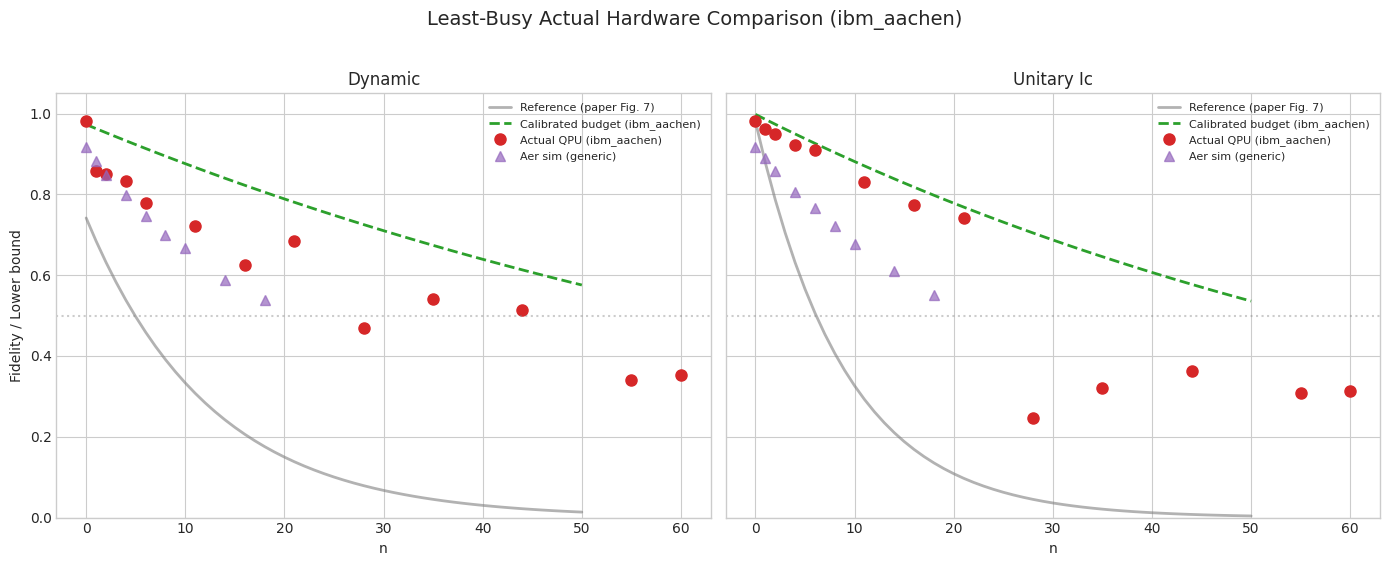

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

plot_backend = real_backend if USE_REAL_BACKEND else backend_ref
plot_budget = REAL_BUDGET if USE_REAL_BACKEND else CALIBRATED_BUDGET
plot_backend_name = plot_backend.name

for ax, impl in zip(axes, IMPLEMENTATIONS):
    ns = np.array(BUDGET_DISTANCES)

    # Reference budget from the paper
    F_ref = [
        np.exp(-compute_lambda_tot(
            table_i_resources(n, impl, DEFAULT_BUDGET_PARAMS["mu"]),
            DEFAULT_BUDGET_PARAMS,
        ))
        for n in ns
    ]
    ax.plot(
        ns,
        F_ref,
        "-",
        color="tab:gray",
        lw=2,
        alpha=0.6,
        label="Reference (paper Fig. 7)",
    )

    # Budget using calibration from the same least-busy hardware backend
    F_cal = [
        np.exp(-compute_lambda_tot(
            table_i_resources(n, impl, plot_budget["mu"]),
            plot_budget,
        ))
        for n in ns
    ]
    ax.plot(
        ns,
        F_cal,
        "--",
        color="tab:green",
        lw=2,
        label=f"Calibrated budget ({plot_backend_name})",
    )

    # Actual QPU results
    if USE_REAL_BACKEND and not real_hw_results.empty:
        sub = real_hw_results[real_hw_results["implementation"] == impl]
        if not sub.empty:
            ax.plot(
                sub["n_ancilla"],
                sub["fidelity_hw"],
                "o",
                color="tab:red",
                ms=8,
                label=f"Actual QPU ({plot_backend_name})",
            )

    # Keep generic Aer sim as a visual reference if available
    gen = results_df[(results_df["implementation"] == impl) & (results_df["noise_model"] == "combined")]
    if not gen.empty:
        ax.plot(
            gen["n_ancilla"],
            gen["fidelity"],
            "^",
            color="tab:purple",
            ms=7,
            alpha=0.7,
            label="Aer sim (generic)",
        )

    ax.set_xlabel("n")
    ax.set_title(impl.replace("_", " ").title())
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", ls=":", alpha=0.4)
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylabel("Fidelity / Lower bound")
fig.suptitle(
    f"Least-Busy Actual Hardware Comparison ({plot_backend_name})",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
fig.savefig(
    "figures/Actual_Hardware_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


NameError: name 'USE_REAL_BACKEND' is not defined

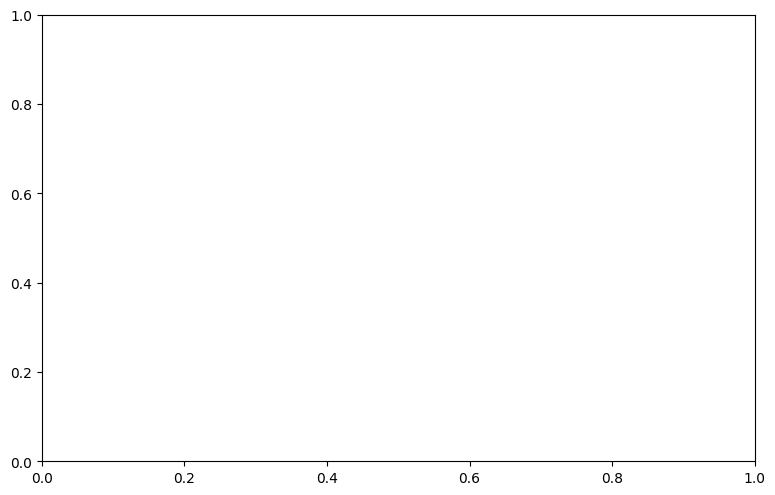

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Combined plot: Actual hardware vs calibrated budget
# Pastel color version for PowerPoint
# ============================================================

fig, ax = plt.subplots(figsize=(9.2, 5.8))

plot_backend = real_backend if USE_REAL_BACKEND else backend_ref
plot_budget = REAL_BUDGET if USE_REAL_BACKEND else CALIBRATED_BUDGET
plot_backend_name = plot_backend.name

# Pastel but distinguishable colors
styles = {
    "dynamic": {
        "label": "Dynamic",
        "main_color": "#4ECDC4",      # pastel teal
        "light_color": "#B8F2E6",     # light mint
        "marker_qpu": "o",
        "marker_aer": "^",
    },
    "unitary_ic": {
        "label": "Unitary Ic",
        "main_color": "#FF8A80",      # pastel coral
        "light_color": "#FFD6D1",     # light coral
        "marker_qpu": "s",
        "marker_aer": "D",
    },
}

for impl in IMPLEMENTATIONS:
    ns = np.array(BUDGET_DISTANCES)
    st = styles[impl]
    impl_label = st["label"]

    # --------------------------------------------------------
    # Reference budget from the paper
    # --------------------------------------------------------
    F_ref = [
        np.exp(-compute_lambda_tot(
            table_i_resources(n, impl, DEFAULT_BUDGET_PARAMS["mu"]),
            DEFAULT_BUDGET_PARAMS,
        ))
        for n in ns
    ]

    ax.plot(
        ns,
        F_ref,
        linestyle=":",
        color="#B8B8B8",
        lw=2.0,
        alpha=0.75,
        label=f"{impl_label}: Reference",
        zorder=1,
    )

    # --------------------------------------------------------
    # Calibrated budget
    # --------------------------------------------------------
    F_cal = [
        np.exp(-compute_lambda_tot(
            table_i_resources(n, impl, plot_budget["mu"]),
            plot_budget,
        ))
        for n in ns
    ]

    ax.plot(
        ns,
        F_cal,
        linestyle="--",
        color=st["light_color"],
        lw=3.2,
        alpha=0.95,
        label=f"{impl_label}: Calibrated budget",
        zorder=2,
    )

    # --------------------------------------------------------
    # Actual QPU results
    # --------------------------------------------------------
    if USE_REAL_BACKEND and not real_hw_results.empty:
        sub = real_hw_results[
            real_hw_results["implementation"] == impl
        ].sort_values("n_ancilla")

        if not sub.empty:
            ax.plot(
                sub["n_ancilla"],
                sub["fidelity_hw"],
                marker=st["marker_qpu"],
                linestyle="-",
                color=st["main_color"],
                lw=2.4,
                ms=8.5,
                markerfacecolor=st["main_color"],
                markeredgecolor="white",
                markeredgewidth=1.3,
                label=f"{impl_label}: Actual QPU",
                zorder=4,
            )

    # --------------------------------------------------------
    # Generic Aer simulation
    # --------------------------------------------------------
    gen = results_df[
        (results_df["implementation"] == impl)
        & (results_df["noise_model"] == "combined")
    ].sort_values("n_ancilla")

    if not gen.empty:
        ax.plot(
            gen["n_ancilla"],
            gen["fidelity"],
            marker=st["marker_aer"],
            linestyle="None",
            color=st["main_color"],
            ms=7.5,
            alpha=0.9,
            markerfacecolor="white",
            markeredgecolor=st["main_color"],
            markeredgewidth=1.8,
            label=f"{impl_label}: Aer sim",
            zorder=3,
        )

# ------------------------------------------------------------
# Figure formatting
# ------------------------------------------------------------
ax.set_xlabel("n", fontsize=12)
ax.set_ylabel("Fidelity / Lower bound", fontsize=12)
ax.set_ylim(0, 1.05)

ax.axhline(
    0.5,
    color="#8A8A8A",
    linestyle=":",
    lw=1.5,
    alpha=0.75,
)

ax.set_title(
    f"Least-Busy Actual Hardware Comparison ({plot_backend_name})",
    fontsize=14,
    pad=14,
)

# Clean PowerPoint-friendly style
ax.grid(True, color="#E8E8E8", linewidth=0.8, alpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")
ax.tick_params(axis="both", colors="#333333", labelsize=10)

# Legend
ax.legend(
    fontsize=8.5,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.32),
    ncol=2,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="#DDDDDD",
)

plt.tight_layout()

# Save figure
os.makedirs("figures", exist_ok=True)

fig.savefig(
    "figures/Actual_Hardware_Comparison_Combined_pastel.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "figures/Actual_Hardware_Comparison_Combined_pastel.pdf",
    bbox_inches="tight",
)

plt.show()

In [26]:
from qiskit.result import marginal_counts

def _final_cr_indices(circuit, register_name="cr"):
    for creg in circuit.cregs:
        if creg.name == register_name:
            return [circuit.clbits.index(bit) for bit in creg]
    raise RuntimeError(f"Register {register_name} not found.")


def ideal_fidelity_after_transpile(backend, impl, n, chain=None, shots=20000):
    logical_qubits = n + 2

    if chain is None:
        chain = find_error_aware_chain(
        backend,
        logical_qubits,
        avoid_qubits=BAD_QUBITS,
        readout_err_limit=READOUT_ERR_LIMIT,
        twoq_err_limit=TWOQ_ERR_LIMIT,
        beam_width=CHAIN_BEAM_WIDTH,
    )

    raw_circuits = build_bell_test_circuits(n, impl)

    pm = _make_pass_manager_for_backend(
        backend,
        initial_layout=chain,
        opt_level=REAL_HW_OPT_LEVEL,
    )

    isa_circuits = pm.run(raw_circuits)

    sim = AerSimulator(seed_simulator=SEED)
    res = sim.run(isa_circuits, shots=shots).result()

    basis_counts = {}

    for i, basis in enumerate(BASES):
        raw_counts = res.get_counts(i)
        cr_indices = _final_cr_indices(isa_circuits[i], "cr")
        counts_2bit = marginal_counts(raw_counts, indices=cr_indices)
        basis_counts[basis] = counts_2bit

    F = bell_fidelity(
        basis_counts["XX"],
        basis_counts["YY"],
        basis_counts["ZZ"],
    )

    print(f"{impl}, n={n}, ideal after transpile fidelity = {F:.4f}")
    print(f"chain = {chain}")
    print(f"ISA depths = {[c.depth() for c in isa_circuits]}")
    print(f"ISA ops = {[c.count_ops() for c in isa_circuits]}")

    return F, isa_circuits, basis_counts

In [27]:
for n in [21, 28, 35, 44, 55, 60]:
    F, isa, counts = ideal_fidelity_after_transpile(
        real_backend,
        "unitary_ic",
        n,
        shots=20000,
    )

unitary_ic, n=21, ideal after transpile fidelity = 1.0000
chain = [40, 41, 42, 43, 56, 63, 64, 65, 77, 85, 86, 87, 97, 107, 106, 105, 104, 103, 96, 83, 82, 81, 80]
ISA depths = [133, 132, 130]
ISA ops = [OrderedDict({'rz': 346, 'sx': 173, 'cz': 85, 'barrier': 3, 'measure': 2}), OrderedDict({'rz': 344, 'sx': 173, 'cz': 85, 'barrier': 3, 'measure': 2}), OrderedDict({'rz': 342, 'sx': 171, 'cz': 85, 'barrier': 3, 'measure': 2})]
unitary_ic, n=28, ideal after transpile fidelity = 1.0000
chain = [100, 101, 102, 103, 96, 83, 84, 85, 86, 87, 97, 107, 108, 109, 118, 129, 130, 131, 138, 151, 152, 153, 154, 155, 139, 135, 134, 133, 119, 113]
ISA depths = [163, 162, 160]
ISA ops = [OrderedDict({'rz': 458, 'sx': 229, 'cz': 113, 'barrier': 3, 'measure': 2}), OrderedDict({'rz': 456, 'sx': 229, 'cz': 113, 'barrier': 3, 'measure': 2}), OrderedDict({'rz': 454, 'sx': 227, 'cz': 113, 'barrier': 3, 'measure': 2})]
unitary_ic, n=35, ideal after transpile fidelity = 1.0000
chain = [40, 41, 42, 43, 56, 63, 64

## Part 7 — Error Budget Consistency

In [28]:
rows = []

if USE_REAL_BACKEND and not real_hw_results.empty:
    source_df = real_hw_results.copy()
    budget = REAL_BUDGET
    fid_col = "fidelity_hw"
    source_label = f"Actual QPU ({real_backend.name})"
else:
    source_df = fake_results.copy()
    budget = CALIBRATED_BUDGET
    fid_col = "fidelity_sim"
    source_label = f"Aer sim ({backend_ref.name})"

for impl in IMPLEMENTATIONS:
    for _, row in source_df[source_df["implementation"] == impl].iterrows():
        n = int(row["n_ancilla"])
        res = table_i_resources(n, impl, budget["mu"])
        it = res["t_idle"] * budget["lambda_idle"]
        ct = res["N_CNOT"] * budget["lambda_cnot"]
        mt = res["N_meas"] * budget["lambda_meas"]
        lt = it + ct + mt
        rows.append({
            "source": source_label,
            "impl": impl,
            "n": n,
            "t_idle": res["t_idle"],
            "N_CNOT": int(res["N_CNOT"]),
            "N_meas": int(res["N_meas"]),
            "lam_idle": round(it, 4),
            "lam_CNOT": round(ct, 4),
            "lam_meas": round(mt, 4),
            "lam_tot": round(lt, 4),
            "F_budget": round(np.exp(-lt), 4),
            "F_measured": round(row[fid_col], 4),
        })

display(pd.DataFrame(rows))


,source,impl,n,t_idle,N_CNOT,N_meas,lam_idle,lam_CNOT,lam_meas,lam_tot,F_budget,F_measured
0,Actual QPU (ibm_aachen),dynamic,0,86.705882,1,0,0.0255,0.0021,0.0000,0.0275,0.9728,0.9810
1,Actual QPU (ibm_aachen),dynamic,1,86.705882,2,2,0.0255,0.0041,0.0084,0.0380,0.9627,0.8569
2,Actual QPU (ibm_aachen),dynamic,2,86.705882,3,4,0.0255,0.0062,0.0169,0.0485,0.9526,0.8501
3,Actual QPU (ibm_aachen),dynamic,4,86.705882,5,8,0.0255,0.0103,0.0338,0.0695,0.9328,0.8320
4,Actual QPU (ibm_aachen),dynamic,6,86.705882,7,12,0.0255,0.0144,0.0506,0.0905,0.9135,0.7783
5,Actual QPU (ibm_aachen),dynamic,11,86.705882,12,22,0.0255,0.0247,0.0928,0.1430,0.8668,0.7227
6,Actual QPU (ibm_aachen),dynamic,16,86.705882,17,32,0.0255,0.0349,0.1351,0.1955,0.8224,0.6255
7,Actual QPU (ibm_aachen),dynamic,21,86.705882,22,42,0.0255,0.0452,0.1773,0.2479,0.7804,0.6841
8,Actual QPU (ibm_aachen),dynamic,28,86.705882,29,56,0.0255,0.0596,0.2363,0.3214,0.7251,0.4697
9,Actual QPU (ibm_aachen),dynamic,35,86.705882,36,70,0.0255,0.0740,0.2954,0.3949,0.6738,0.5400


## Discussion

### Dominant noise source

- **Gate error (depolarizing)**: Dynamic CNOT의 주요 오류원. n+1개의 2Q gate에서 누적.
- **Readout error**: n개의 mid-circuit measurement에서 기여. 두 번째로 중요.
- **Thermal relaxation**: Feed-forward idle time 동안 발생하나, O(1) depth로 상수 offset.

### Error budget 일관성

$$\lambda_{\text{tot}} = t_{\text{idle}}\lambda_{\text{idle}} + N_{\text{CNOT}}\lambda_{\text{CNOT}} + N_{\text{meas}}\lambda_{\text{meas}}$$

- **Unitary Ic**: $(4n+1)\lambda_{\text{CNOT}}$ — slope 4배 빠름
- **Dynamic**: $(n+1)\lambda_{\text{CNOT}} + n\lambda_{\text{meas}} + (2\mu+2)\lambda_{\text{idle}}$
- **Crossover**: $\lambda_{\text{meas}} < 3\lambda_{\text{CNOT}}$일 때 dynamic이 유리

### Key insight

Mid-circuit measurement error 감소가 dynamic circuit 경쟁력에 가장 큰 영향. Analytical budget $e^{-\lambda}$는 lower bound (Lemma 1)이며, 실제 simulation보다 보수적.

## Appendix: Parameter Summary

In [29]:
summary_data = {
    "Parameter": ["lambda_idle", "lambda_CNOT", "lambda_meas", "mu", "3*lambda_CNOT", "crossover?"],
    "Reference (paper)": [
        f"{DEFAULT_BUDGET_PARAMS['lambda_idle']:.4f}",
        f"{DEFAULT_BUDGET_PARAMS['lambda_cnot']:.4f}",
        f"{DEFAULT_BUDGET_PARAMS['lambda_meas']:.4f}",
        f"{DEFAULT_BUDGET_PARAMS['mu']:.2f}",
        f"{3 * DEFAULT_BUDGET_PARAMS['lambda_cnot']:.4f}",
        str(DEFAULT_BUDGET_PARAMS['lambda_meas'] < 3 * DEFAULT_BUDGET_PARAMS['lambda_cnot']),
    ],
    f"Calibrated ({backend_ref.name})": [
        f"{CALIBRATED_BUDGET['lambda_idle']:.6f}",
        f"{CALIBRATED_BUDGET['lambda_cnot']:.6f}",
        f"{CALIBRATED_BUDGET['lambda_meas']:.6f}",
        f"{CALIBRATED_BUDGET['mu']:.3f}",
        f"{3 * CALIBRATED_BUDGET['lambda_cnot']:.6f}",
        str(CALIBRATED_BUDGET['lambda_meas'] < 3 * CALIBRATED_BUDGET['lambda_cnot']),
    ],
}

if USE_REAL_BACKEND:
    summary_data[f"Actual hardware calibration ({real_backend.name})"] = [
        f"{REAL_BUDGET['lambda_idle']:.6f}",
        f"{REAL_BUDGET['lambda_cnot']:.6f}",
        f"{REAL_BUDGET['lambda_meas']:.6f}",
        f"{REAL_BUDGET['mu']:.3f}",
        f"{3 * REAL_BUDGET['lambda_cnot']:.6f}",
        str(REAL_BUDGET['lambda_meas'] < 3 * REAL_BUDGET['lambda_cnot']),
    ]

summary = pd.DataFrame(summary_data)
display(summary)

print("\n=== Table I Resource Counts ===")
active_budget = REAL_BUDGET if USE_REAL_BACKEND else CALIBRATED_BUDGET
for impl in IMPLEMENTATIONS:
    for n in [0, 5, 10, 20, 40]:
        r = table_i_resources(n, impl, active_budget["mu"])
        print(
            f"  {impl:12s} n={n:2d}:  t_idle={r['t_idle']:6.1f}  "
            f"N_CNOT={r['N_CNOT']:3.0f}  N_meas={r['N_meas']:2.0f}  depth_2q={r['depth_2q']:5.1f}"
        )


,Parameter,Reference (paper),Calibrated (fake_brisbane),Actual hardware calibration (ibm_aachen)
0,lambda_idle,0.0300,0.003622,0.000294
1,lambda_CNOT,0.0200,0.009696,0.002055
2,lambda_meas,0.0300,0.023092,0.004220
3,mu,3.65,3.030,42.353
4,3*lambda_CNOT,0.0600,0.029088,0.006164
5,crossover?,True,True,True



=== Table I Resource Counts ===
  dynamic      n= 0:  t_idle=  86.7  N_CNOT=  1  N_meas= 0  depth_2q= 44.4
  dynamic      n= 5:  t_idle=  86.7  N_CNOT=  6  N_meas=10  depth_2q= 44.4
  dynamic      n=10:  t_idle=  86.7  N_CNOT= 11  N_meas=20  depth_2q= 44.4
  dynamic      n=20:  t_idle=  86.7  N_CNOT= 21  N_meas=40  depth_2q= 44.4
  dynamic      n=40:  t_idle=  86.7  N_CNOT= 41  N_meas=80  depth_2q= 44.4
  unitary_ic   n= 0:  t_idle=   0.0  N_CNOT=  1  N_meas= 0  depth_2q=  1.0
  unitary_ic   n= 5:  t_idle=   0.0  N_CNOT= 21  N_meas= 5  depth_2q= 11.0
  unitary_ic   n=10:  t_idle=   0.0  N_CNOT= 41  N_meas=10  depth_2q= 21.0
  unitary_ic   n=20:  t_idle=   0.0  N_CNOT= 81  N_meas=20  depth_2q= 41.0
  unitary_ic   n=40:  t_idle=   0.0  N_CNOT=161  N_meas=40  depth_2q= 81.0
